<a href="https://www.kaggle.com/code/hugogrou/projeto-cdg?scriptVersionId=313577601" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Inspeção, EDA Profunda e Pré-Processamento do Dataset

**Feito por: Bernardo e Hugo**

## Nota Técnica: Estratégia de Amostragem

O dataset Avazu CTR Prediction contém **40.428.967 registos**, o que inviabiliza o carregamento direto com `pd.read_csv()` (esgota a RAM do Kaggle) e impossibilita o upload para o GitHub.

Por sugestão da professora, foi adoptada uma **amostra aleatória de 5.000.000 registos** (`random_state=42`), garantindo:
- **Reprodutibilidade total**: a mesma semente produz sempre a mesma amostra
- **Representatividade estatística**: amostragem aleatória simples sem viés
- **Compatibilidade com o Kaggle**: ~2 GB em memória, dentro dos limites

Todas as células seguintes operam sobre este `df` — **não recarregar o ficheiro**.

In [1]:
# Imports e setup 
# Bibliotecas usadas em todo o notebook:
#   - numpy, pandas: manipulação numérica e tabular
#   - matplotlib, seaborn: visualização
#   - IPython.display.display: renderização de DataFrames em Jupyter
#   - defaultdict: estruturas auxiliares (secções de EDA)
#   - warnings: suprimir avisos ruidosos do pandas/sklearn
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# ── Listagem dos ficheiros disponíveis no ambiente Kaggle ─────────
# Percorre /kaggle/input para confirmar a presença do dataset.
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/sampleSubmission/sampleSubmission.csv
/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/test/test.csv
/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv


## 1. Carregamento da Amostra (5 Milhões de Registos)

A amostra é seleccionada aleatoriamente com semente fixa (`random_state=42`).
Todas as células seguintes utilizam este mesmo `df` — **não recarregar o ficheiro**.

In [2]:
#  Carregamento da amostra estratificada
# Parâmetros de amostragem. Alterar APENAS nesta secção para garantir
# consistência em todas as células seguintes.

FILE_PATH     = "/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv"
TOTAL_ROWS    = 40_428_967   # total de linhas no ficheiro original (sem header)
SAMPLE_SIZE   = 5_000_000    # amostra sugerida pela professora
RANDOM_STATE  = 42            # semente fixa — NÃO alterar (garante reprodutibilidade)

# ── Construção do conjunto de índices a carregar ──────────────────
# np.random.choice com replace=False assegura amostragem sem reposição.
# keep_indices é convertido para set → lookup O(1) dentro do skiprows lambda.
np.random.seed(RANDOM_STATE)
keep_indices = set(np.random.choice(TOTAL_ROWS, size=SAMPLE_SIZE, replace=False))

print(f"A carregar {SAMPLE_SIZE:,} registos aleatórios de {TOTAL_ROWS:,} "
      f"({SAMPLE_SIZE/TOTAL_ROWS*100:.1f}%)...")

# ── Leitura do CSV com skiprows dinâmico ──────────────────────────
# skiprows recebe uma função que devolve True se a linha deve ser IGNORADA.
# A linha 0 (header) é sempre mantida; as restantes são filtradas por keep_indices.
df = pd.read_csv(
    FILE_PATH,
    skiprows=lambda i: i > 0 and (i - 1) not in keep_indices
)
df = df.reset_index(drop=True)

print(f"\n  Amostra carregada com sucesso!")
print(f"   Dimensão: {df.shape[0]:,} registos × {df.shape[1]} colunas")
print(f"   Memória aproximada: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")


A carregar 5,000,000 registos aleatórios de 40,428,967 (12.4%)...

  Amostra carregada com sucesso!
   Dimensão: 5,000,000 registos × 24 colunas
   Memória aproximada: 3165.0 MB


## 2. Inspeção da Amostra Bruta

Análise inicial completa: dimensões, primeiras linhas, tipos, nulos, estatísticas numéricas e categóricas.

In [3]:
#  Inspeção inicial do dataset
# Relatório estruturado em cinco blocos: dimensão, primeiras linhas,
# tipos de dados, nulos, e estatísticas descritivas (numéricas e categóricas).

# Bloco 1: Dimensão ────────────────────────────────────────────────
print("=" * 60)
print("DIMENSÃO")
print(f"  {df.shape[0]:,} registos × {df.shape[1]} colunas")

# Bloco 2: Amostra das primeiras linhas ────────────────────────────
print("\nPRIMEIRAS 5 LINHAS")
display(df.head())

# Bloco 3: Tipos de dados de cada coluna ───────────────────────────
# Útil para detetar inconsistências (ex.: numéricos lidos como object).
print("\nTIPOS DE DADOS")
display(df.dtypes.to_frame("Tipo"))

# Bloco 4: Contagem de nulos por coluna ────────────────────────────
# O dataset Avazu não costuma ter NaN explícitos, mas sim valores -1 mascarados.
# Essa deteção é feita na secção 3 (Integridade).
print("\nVALORES NULOS")
null_counts = df.isnull().sum()
display(null_counts.to_frame("Nulos"))
print(f"Total de valores nulos: {int(null_counts.sum())}")

# Bloco 5a: Estatísticas descritivas das variáveis numéricas ───────
print("\nESTATÍSTICAS NUMÉRICAS")
display(df.describe())

# Bloco 5b: Estatísticas das variáveis categóricas ─────────────────
# Para cada coluna categórica: contagem de não-nulos, cardinalidade,
# categoria mais frequente (top) e sua frequência absoluta (freq).
print("\nESTATÍSTICAS CATEGÓRICAS")
cat_cols = df.select_dtypes(include="object").columns.tolist()
if cat_cols:
    cat_summary = {}
    for col in cat_cols:
        vc = df[col].value_counts()
        cat_summary[col] = {
            "count":  df[col].notna().sum(),
            "unique": df[col].nunique(),
            "top":    vc.index[0],
            "freq":   int(vc.iloc[0])
        }
    display(pd.DataFrame(cat_summary).T)
else:
    print("  Sem colunas categóricas.")


DIMENSÃO
  5,000,000 registos × 24 colunas

PRIMEIRAS 5 LINHAS


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,10000371904215119486,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
1,10001264480619467364,0,14102100,1002,0,84c7ba46,c4e18dd6,50e219e0,ecad2386,7801e8d9,...,0,0,21689,320,50,2496,3,167,100191,23
2,10004670021948955159,0,14102100,1005,0,543a539e,c7ca3108,3e814130,ecad2386,7801e8d9,...,1,0,20366,320,50,2333,0,39,-1,157
3,10007847530896919634,1,14102100,1002,0,84c7ba46,c4e18dd6,50e219e0,ecad2386,7801e8d9,...,0,0,21661,320,50,2446,3,171,100228,156
4,10010966574628106108,1,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,0acbeaa3,45a51db4,...,1,0,20596,320,50,2161,0,35,100034,157



TIPOS DE DADOS


,Tipo
id,uint64
click,int64
hour,int64
C1,int64
banner_pos,int64
site_id,object
site_domain,object
site_category,object
app_id,object
app_domain,object



VALORES NULOS


,Nulos
id,0
click,0
hour,0
C1,0
banner_pos,0
site_id,0
site_domain,0
site_category,0
app_id,0
app_domain,0


Total de valores nulos: 0

ESTATÍSTICAS NUMÉRICAS


,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
count,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,9.223480e+18,1.697188e-01,1.410256e+07,1.004968e+03,2.881012e-01,1.015408e+00,3.300478e-01,1.884259e+04,3.188800e+02,6.005896e+01,2.112686e+03,1.432106e+00,2.272310e+02,5.317426e+04,8.340489e+01
std,5.325474e+18,3.753856e-01,2.967201e+02,1.095621e+00,5.057768e-01,5.279241e-01,8.530219e-01,4.958047e+03,2.123737e+01,4.722027e+01,6.092178e+02,1.326446e+00,3.510607e+02,4.995947e+04,7.029536e+01
min,5.211594e+11,0.000000e+00,1.410210e+07,1.001000e+03,0.000000e+00,0.000000e+00,0.000000e+00,3.750000e+02,1.200000e+02,2.000000e+01,1.120000e+02,0.000000e+00,3.300000e+01,-1.000000e+00,1.000000e+00
25%,4.609911e+18,0.000000e+00,1.410230e+07,1.005000e+03,0.000000e+00,1.000000e+00,0.000000e+00,1.692000e+04,3.200000e+02,5.000000e+01,1.863000e+03,0.000000e+00,3.500000e+01,-1.000000e+00,2.300000e+01
50%,9.226424e+18,0.000000e+00,1.410260e+07,1.005000e+03,0.000000e+00,1.000000e+00,0.000000e+00,2.034600e+04,3.200000e+02,5.000000e+01,2.323000e+03,2.000000e+00,3.900000e+01,1.000480e+05,6.100000e+01
75%,1.383619e+19,0.000000e+00,1.410281e+07,1.005000e+03,1.000000e+00,1.000000e+00,0.000000e+00,2.189400e+04,3.200000e+02,5.000000e+01,2.526000e+03,3.000000e+00,1.710000e+02,1.000880e+05,1.010000e+02
max,1.844674e+19,1.000000e+00,1.410302e+07,1.012000e+03,7.000000e+00,5.000000e+00,5.000000e+00,2.405200e+04,1.024000e+03,1.024000e+03,2.758000e+03,3.000000e+00,1.959000e+03,1.002480e+05,2.550000e+02



ESTATÍSTICAS CATEGÓRICAS


,count,unique,top,freq
site_id,5000000,3552,85f751fd,1804850
site_domain,5000000,4523,c4e18dd6,1871216
site_category,5000000,22,50e219e0,2044793
app_id,5000000,5239,ecad2386,3195150
app_domain,5000000,340,7801e8d9,3369186
app_category,5000000,31,07d7df22,3236597
device_id,5000000,598510,a99f214a,4126150
device_ip,5000000,1904861,6b9769f2,26025
device_model,5000000,6509,8a4875bd,304562


## 3. Integridade dos Dados

Verificação de tipos esperados vs reais, deteção de valores `-1` mascarados nas colunas anónimas (C14–C21) e missing values não-standard.

In [4]:
# Verificação de integridade dos dados
# Objetivo duplo:
#   (a) confirmar que cada coluna tem o tipo esperado segundo a documentação Avazu;
#   (b) quantificar valores -1 mascarados nas colunas anónimas C14–C21, que o
#       dataset usa como código para "missing" em vez de NaN.

# ── Dicionário de tipos esperados ─────────────────────────────────
# Construído a partir da documentação oficial do dataset Avazu CTR Prediction.
expected_types = {
    'id': 'float64', 'click': 'int64', 'hour': 'int64', 'C1': 'int64',
    'banner_pos': 'int64', 'site_id': 'object', 'site_domain': 'object',
    'site_category': 'object', 'app_id': 'object', 'app_domain': 'object',
    'app_category': 'object', 'device_id': 'object', 'device_ip': 'object',
    'device_model': 'object', 'device_type': 'int64', 'device_conn_type': 'int64',
    'C14': 'int64', 'C15': 'int64', 'C16': 'int64', 'C17': 'int64',
    'C18': 'int64', 'C19': 'int64', 'C20': 'int64', 'C21': 'int64'
}

# ── Comparação tipo real vs. tipo esperado ────────────────────────
print(f"{'Coluna':<22} {'Tipo Real':<15} {'Tipo Esperado':<15} {'OK?':<6}")
print('-' * 70)
for col, exp in expected_types.items():
    if col not in df.columns:
        continue
    real = str(df[col].dtype)
    ok = 'Sim' if real == exp else 'Não'
    print(f"{col:<22} {real:<15} {exp:<15} {ok}")

# ── Deteção de valores -1 nas colunas anónimas C14–C21 ───────────
# Em variáveis ​​numéricas, um -1 "fora de escala" é o código típico para valor
# em falta/desconhecido no Avazu. A percentagem ajuda a decidir se vale a pena
# imputar (ver secção 5 — Pré-processamento).
cols_anonimas = [f'C{i}' for i in range(14, 22)]
print("\nValores -1 mascarados nas colunas anónimas:")
print(f"{'Coluna':<10} {'Count -1':>12} {'%':>8}")
print('-' * 32)
for col in cols_anonimas:
    if col in df.columns:
        n_neg = (df[col] == -1).sum()
        pct = n_neg / len(df) * 100
        print(f"{col:<10} {n_neg:>12,} {pct:>7.2f}%")


Coluna                 Tipo Real       Tipo Esperado   OK?   
----------------------------------------------------------------------
id                     uint64          float64         Não
click                  int64           int64           Sim
hour                   int64           int64           Sim
C1                     int64           int64           Sim
banner_pos             int64           int64           Sim
site_id                object          object          Sim
site_domain            object          object          Sim
site_category          object          object          Sim
app_id                 object          object          Sim
app_domain             object          object          Sim
app_category           object          object          Sim
device_id              object          object          Sim
device_ip              object          object          Sim
device_model           object          object          Sim
device_type            int64           in

### 3.1 Análise de Observações Repetidas

Em datasets de publicidade digital como o Avazu, linhas exatamente duplicadas podem ter dois significados distintos:

1. **Duplicados legítimos** — o mesmo utilizador é exposto ao mesmo anúncio mais do que uma vez no mesmo bloco horário, gerando registos idênticos. Remover estes duplicados distorceria a frequência real de exposição.
2. **Duplicados falsos** — erros de ingestão ou de *tracking* que inflacionam artificialmente o dataset.

Esta secção quantifica duplicados em três granularidades (linha completa, `id`, e combinação utilizador+momento+anúncio), permitindo uma decisão informada sobre se devem ou não ser removidos.


In [5]:
# Análise de Observações Repetidas 
print('ANÁLISE DE DUPLICADOS')

# ── Nível 1: Linhas completamente duplicadas ──────────────────────
# Todas as colunas iguais — indicaria potencial erro de ingestão.
n_dup_total = df.duplicated().sum()
print(f'\n1. Linhas totalmente duplicadas (todas as colunas iguais):')
print(f'   {n_dup_total:,} registos ({n_dup_total/len(df)*100:.4f}%)')

# ── Nível 2: Duplicados por identificador único (`id`) ────────────
# O campo 'id' deveria ser único por registo no dataset original.
if 'id' in df.columns:
    n_dup_id = df['id'].duplicated().sum()
    print(f'\n2. Duplicados por campo `id` (devia ser único):')
    print(f'   {n_dup_id:,} registos ({n_dup_id/len(df)*100:.4f}%)')

# ── Nível 3: "Duplicados lógicos" — mesmo utilizador, mesmo momento, mesmo anúncio ──
# Mesmo device_ip + device_id + hour + site_id + app_id → provavelmente a mesma
# impressão repetida, legítima em RTB mas vale a pena quantificar.
cols_logicas = [c for c in ['device_ip', 'device_id', 'hour', 'site_id', 'app_id']
                if c in df.columns]
if len(cols_logicas) >= 3:
    n_dup_logico = df.duplicated(subset=cols_logicas).sum()
    print(f'\n3. Duplicados lógicos (mesmo utilizador+momento+anúncio):')
    print(f'   Subset: {cols_logicas}')
    print(f'   {n_dup_logico:,} registos ({n_dup_logico/len(df)*100:.4f}%)')

# ── Decisão e justificação ────────────────────────────────────────
print('DECISÃO')
if n_dup_total == 0:
    print('  Não existem linhas totalmente duplicadas — nenhuma remoção necessária.')
    print('   (Os duplicados lógicos, se existirem, são impressões legítimas em RTB e')
    print('    devem ser preservados: refletem a frequência real de exposição.)')
else:
    print(f'  Detetadas {n_dup_total:,} linhas totalmente duplicadas.')
    print('   Opção conservadora: manter (podem refletir impressões repetidas legítimas).')
    print('   Opção estrita: remover com df = df.drop_duplicates().')
    print('   Neste projeto optámos por MANTER — a coluna `id` garante rastreabilidade')
    print('   e a modelação beneficia de ver múltiplas exposições ao mesmo anúncio.')


ANÁLISE DE DUPLICADOS

1. Linhas totalmente duplicadas (todas as colunas iguais):
   0 registos (0.0000%)

2. Duplicados por campo `id` (devia ser único):
   0 registos (0.0000%)

3. Duplicados lógicos (mesmo utilizador+momento+anúncio):
   Subset: ['device_ip', 'device_id', 'hour', 'site_id', 'app_id']
   1,130,966 registos (22.6193%)
DECISÃO
  Não existem linhas totalmente duplicadas — nenhuma remoção necessária.
   (Os duplicados lógicos, se existirem, são impressões legítimas em RTB e
    devem ser preservados: refletem a frequência real de exposição.)


## 4. Análise Exploratória (EDA)

Análise aprofundada da distribuição das variáveis, desequilíbrio de classes, outliers e padrões bivariados.

### 4.1 Distribuição da Variável Alvo (`click`)

Visualização do desequilíbrio de classes — essencial para justificar o uso de AUC-ROC como métrica principal.

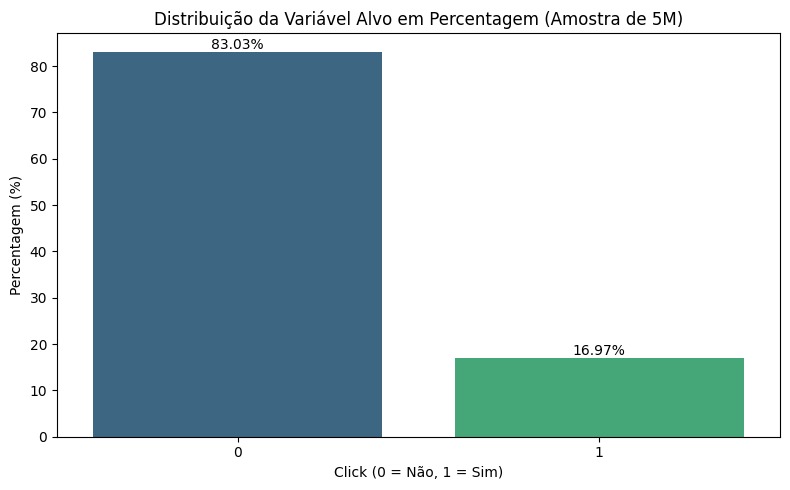

Cliques  (1): 848,594 (16.97%)
Não-cliques (0): 4,151,406 (83.03%)
Rácio desbalanceamento: 1:4


In [6]:
target_counts = df['click'].value_counts()
total = target_counts.sum()
target_pct = (target_counts / total) * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=target_pct.index, y=target_pct.values,
                 hue=target_pct.index, palette='viridis', legend=False)
plt.title('Distribuição da Variável Alvo em Percentagem (Amostra de 5M)')
plt.xlabel('Click (0 = Não, 1 = Sim)')
plt.ylabel('Percentagem (%)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

print(f"Cliques  (1): {int(target_counts[1]):,} ({target_pct[1]:.2f}%)")
print(f"Não-cliques (0): {int(target_counts[0]):,} ({target_pct[0]:.2f}%)")
print(f"Rácio desbalanceamento: 1:{target_counts[0]//target_counts[1]:.0f}")

### 4.2 Top 10 Categorias nas Variáveis mais Relevantes

Distribuição de frequências das variáveis categóricas e semi-categóricas chave para o objectivo de CTR.

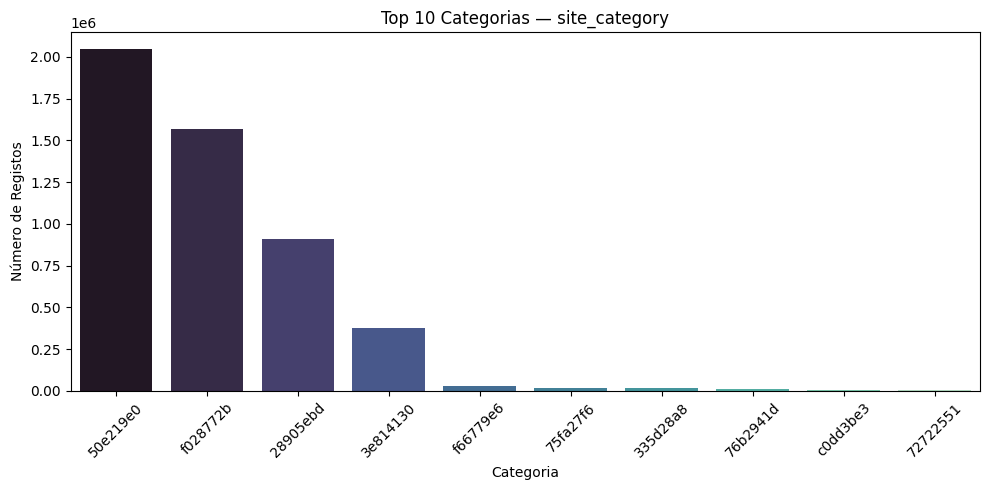

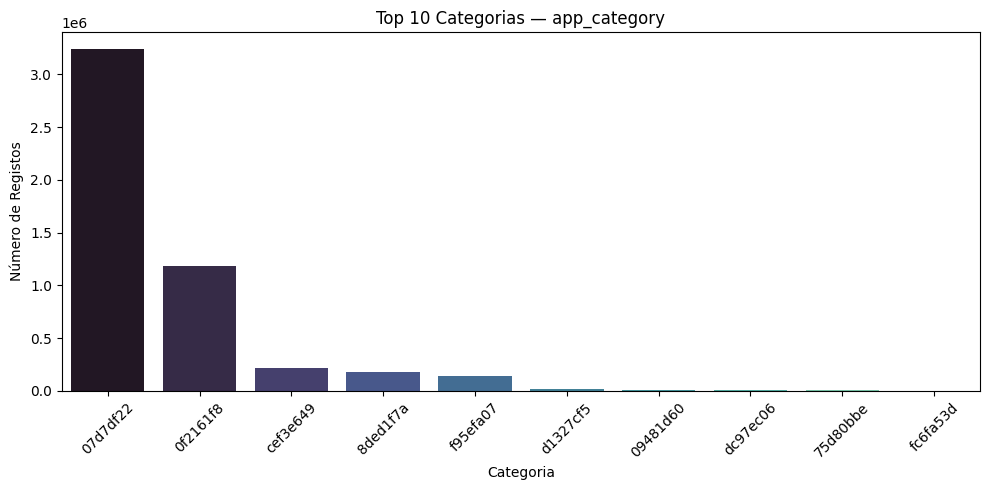

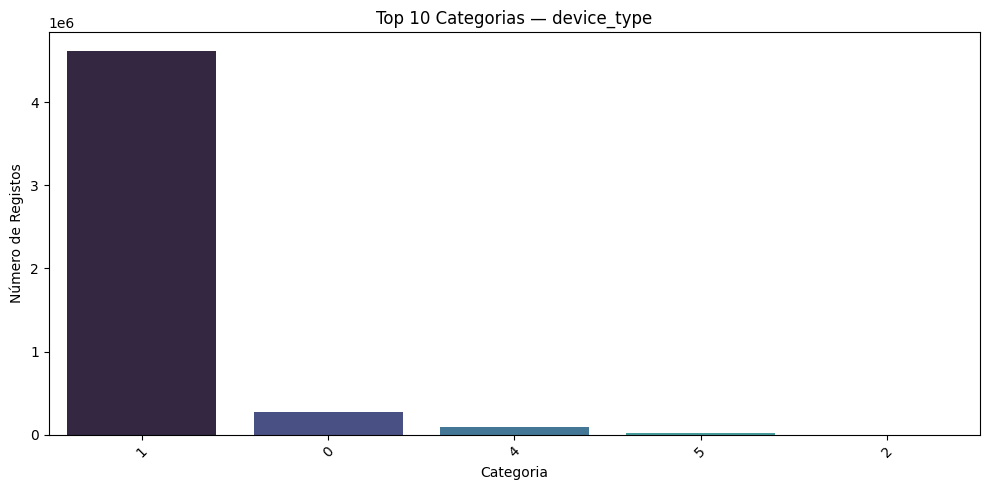

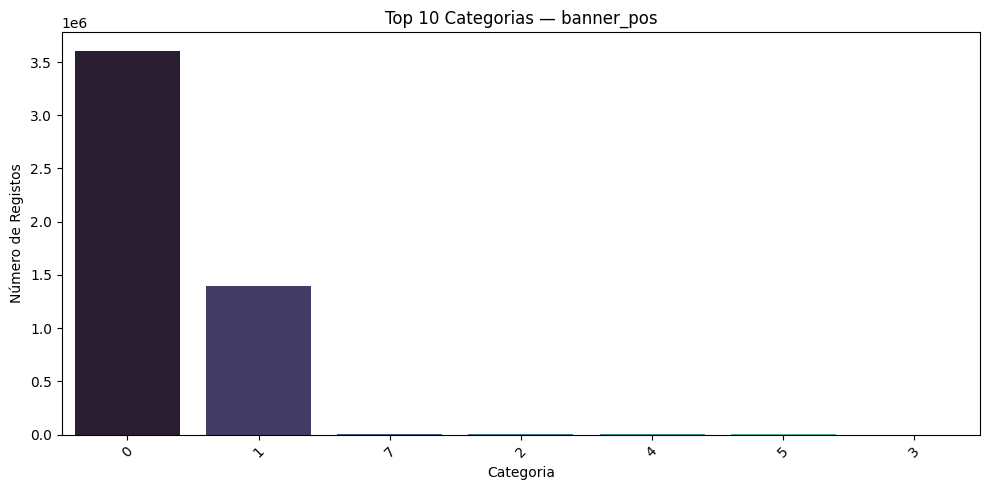

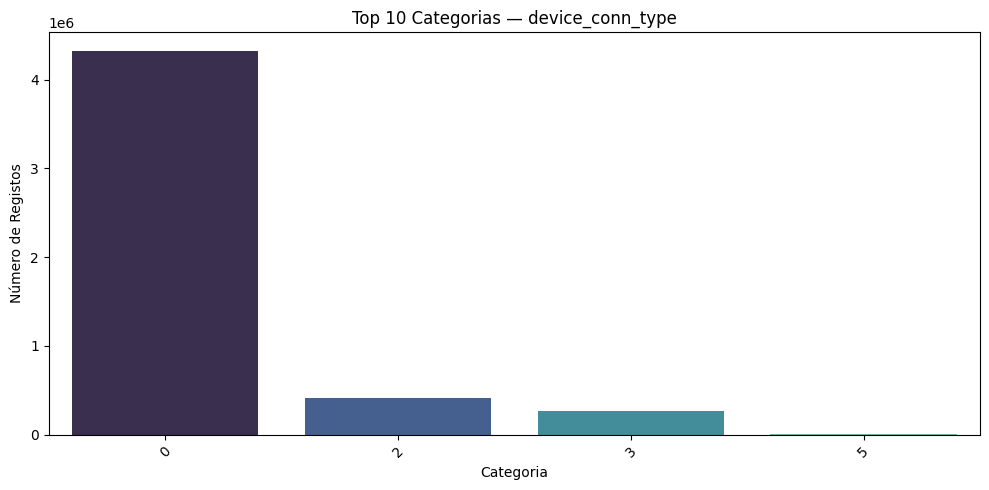

In [7]:
colunas_alvo = ['site_category', 'app_category', 'device_type', 'banner_pos', 'device_conn_type']

for col in colunas_alvo:
    contagem = df[col].astype(str).value_counts()
    if '-1' in contagem.index:
        contagem = contagem.rename({'-1': 'Desconhecido'})
    top_10 = contagem.head(10)

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x=top_10.index, y=top_10.values,
                     hue=top_10.index, palette='mako', legend=False)
    plt.title(f'Top 10 Categorias — {col}')
    plt.xlabel('Categoria')
    plt.ylabel('Número de Registos')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 4.3 Distribuição e Outliers nas Variáveis Numéricas

Boxplots para identificação de outliers e histogramas com escala logarítmica para visualizar a distribuição completa das variáveis numéricas.

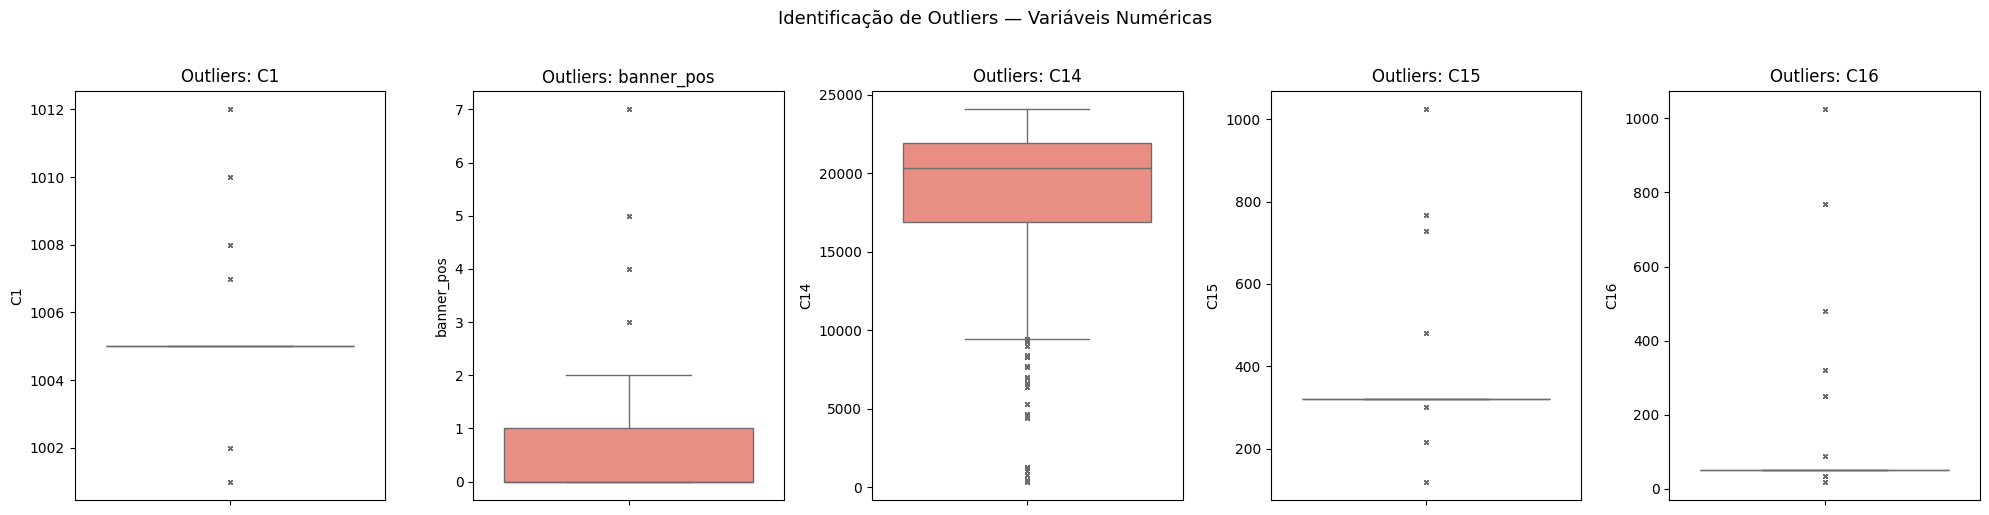

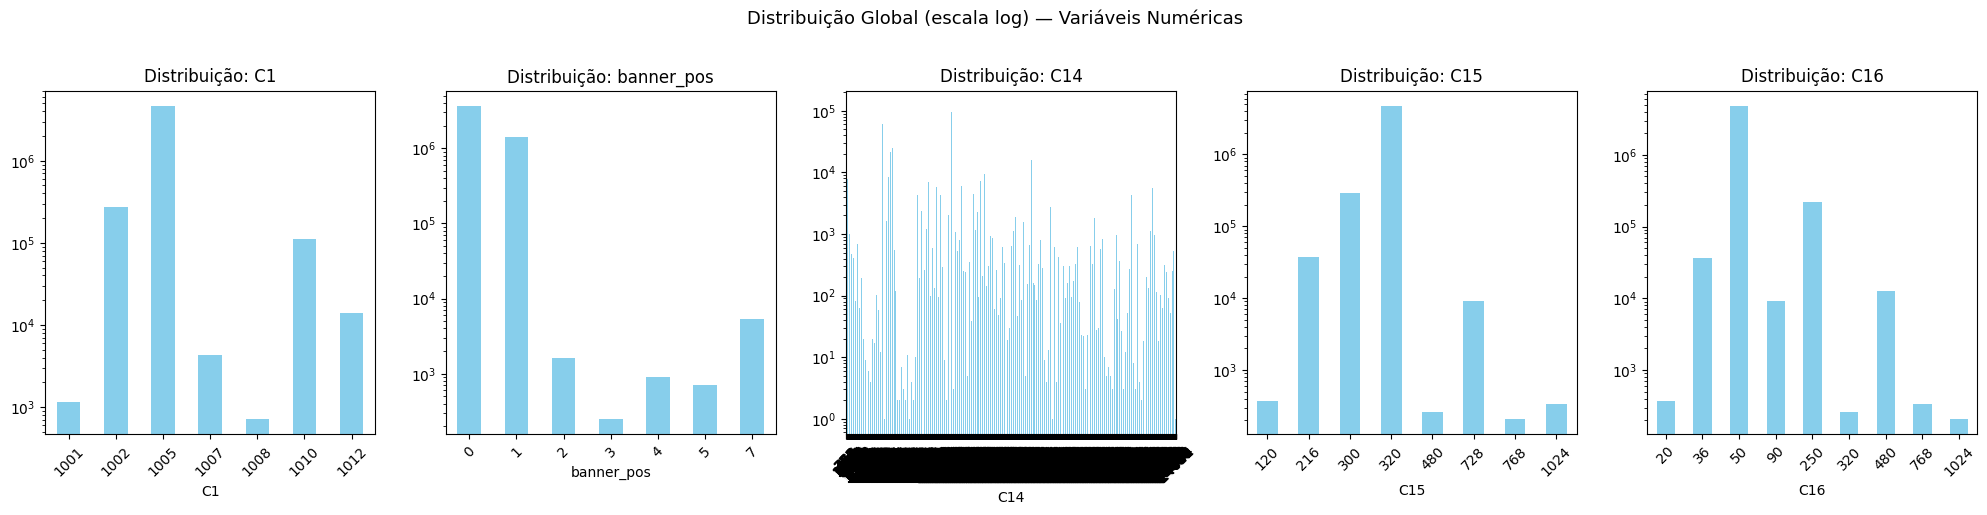

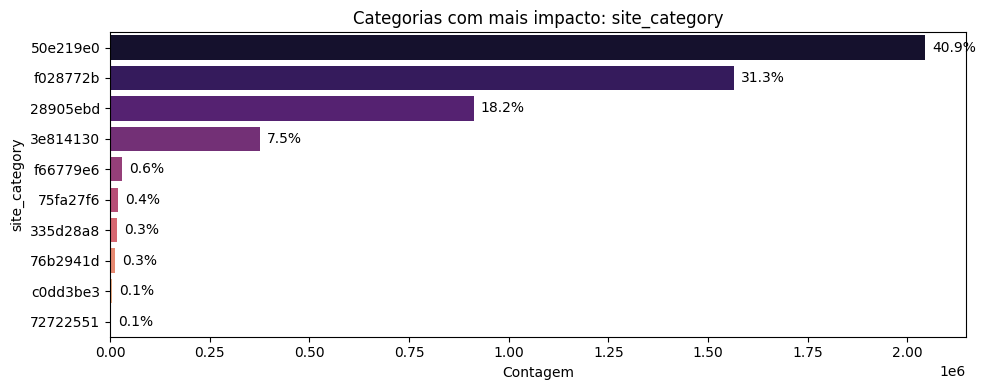

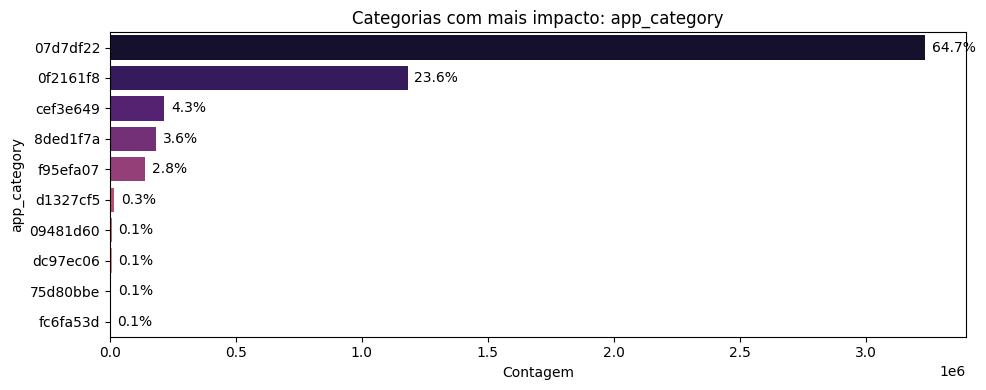

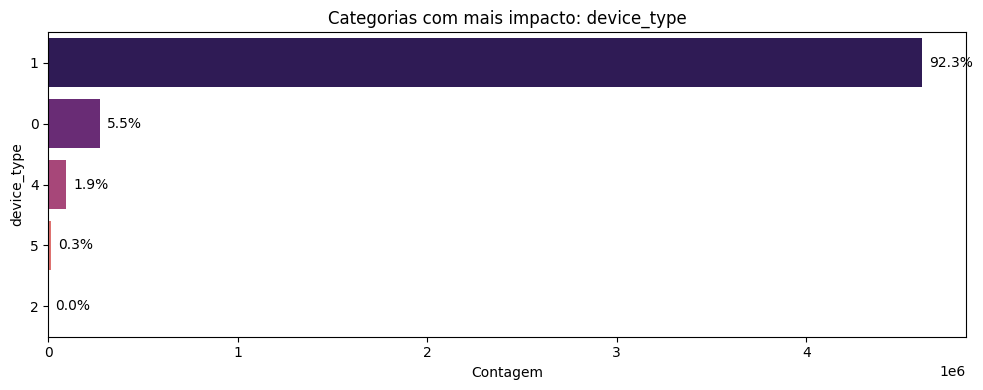

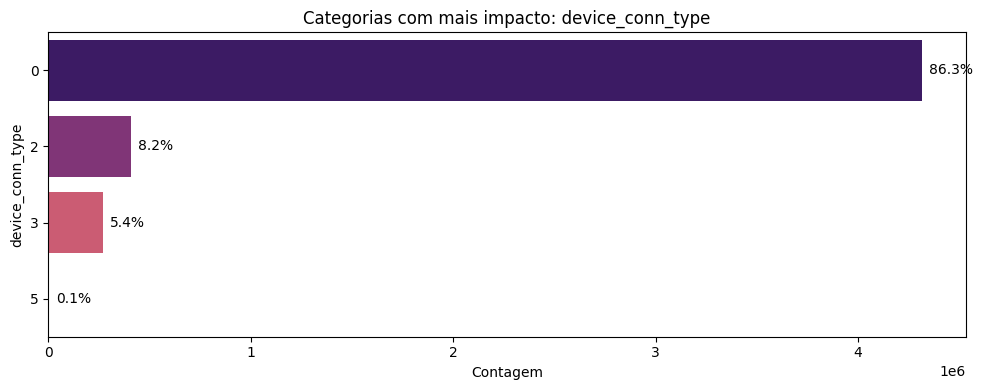

In [8]:
cols_numericas = ['C1', 'banner_pos', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21',
                  'device_type', 'device_conn_type']

# Boxplots
plt.figure(figsize=(20, 5))
cols_box = ['C1', 'banner_pos', 'C14', 'C15', 'C16']
for i, col in enumerate(cols_box):
    plt.subplot(1, 5, i + 1)
    sns.boxplot(y=df[col], color='salmon',
                flierprops={'marker': 'x', 'markerfacecolor': 'red', 'markersize': 3})
    plt.title(f'Outliers: {col}')
plt.suptitle('Identificação de Outliers — Variáveis Numéricas', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Histogramas (escala log) ─────────────────────────────────
plt.figure(figsize=(20, 5))
for i, col in enumerate(cols_box):
    plt.subplot(1, 5, i + 1)
    df[col].value_counts().sort_index().plot(kind='bar', color='skyblue', ax=plt.gca())
    plt.yscale('log')
    plt.title(f'Distribuição: {col}')
    plt.xticks(rotation=45)
plt.suptitle('Distribuição Global (escala log) — Variáveis Numéricas', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Frequência categórica com percentagens 
cols_cat_num = ['site_category', 'app_category', 'device_type', 'device_conn_type']
for col in cols_cat_num:
    plt.figure(figsize=(10, 4))
    top_10 = df[col].astype(str).value_counts().head(10)
    ax = sns.barplot(x=top_10.values, y=top_10.index,
                     hue=top_10.index, palette='magma', legend=False)
    total_col = top_10.sum()
    for p in ax.patches:
        pct = '{:.1f}%'.format(100 * p.get_width() / df[col].count())
        ax.annotate(pct, (p.get_width(), p.get_y() + p.get_height() / 2),
                    xytext=(5, 0), textcoords='offset points', va='center')
    plt.title(f'Categorias com mais impacto: {col}')
    plt.xlabel('Contagem')
    plt.tight_layout()
    plt.show()

### 4.4 Tabela de Outliers por IQR

Cálculo rigoroso do total de outliers por coluna numérica usando o método IQR (Q1 − 1.5×IQR, Q3 + 1.5×IQR).

In [9]:
#  Função utilitária para deteção de outliers 
def calcular_outliers_iqr(df, cols):
    """
    Deteta outliers em variáveis numéricas usando o método do Intervalo
    Interquartil (IQR).

    Um valor é considerado outlier se estiver fora do intervalo:
        [Q1 - 1.5·IQR, Q3 + 1.5·IQR]
    onde IQR = Q3 - Q1 (intervalo entre o 1.º e o 3.º quartis).

    Esta é a regra de Tukey, preferida a critérios baseados em desvio padrão
    porque não assume distribuição Normal — adequada a variáveis discretas/
    desequilibradas como as C14–C21 do Avazu.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame contendo as colunas a analisar.
    cols : list[str]
        Lista de nomes de colunas numéricas a processar.

    Devolve
    -------
    pd.DataFrame com uma linha por coluna analisada, contendo:
        - 'Coluna'     : nome da coluna
        - 'Outliers'   : contagem absoluta de outliers
        - '% Total'    : percentagem de outliers sobre o total de não-nulos
        - 'Limite Inf' : limite inferior calculado (Q1 - 1.5·IQR)
        - 'Limite Sup' : limite superior calculado (Q3 + 1.5·IQR)
    """
    resultados = []
    print(f"{'Coluna':<20} | {'Outliers':>12} | {'% Total':>8} | {'Limite Inf':>12} | {'Limite Sup':>12}")
    print('-' * 72)
    for col in cols:
        if col not in df.columns:
            continue
        # Remover NaN antes de calcular quartis (evita propagação de missing).
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        # Regra de Tukey: 1.5·IQR para outliers "ligeiros" (3·IQR para extremos).
        li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((s < li) | (s > ls)).sum()
        pct = n_out / len(s) * 100
        resultados.append({'Coluna': col, 'Outliers': int(n_out),
                            '% Total': round(pct, 2),
                            'Limite Inf': round(li, 2), 'Limite Sup': round(ls, 2)})
        print(f"{col:<20} | {n_out:>12,} | {pct:>7.2f}% | {li:>12.2f} | {ls:>12.2f}")
    return pd.DataFrame(resultados)


# Colunas numéricas relevantes (inclui as anónimas C14–C21 e variáveis técnicas)
cols_num_iqr = ['C1', 'banner_pos', 'C14', 'C15', 'C16', 'C17',
                'C18', 'C19', 'C20', 'C21', 'device_type', 'device_conn_type']

# Aplicar a função e mostrar a tabela consolidada
df_outliers = calcular_outliers_iqr(df, cols_num_iqr)
print("\nTabela resumo:")
display(df_outliers)


Coluna               |     Outliers |  % Total |   Limite Inf |   Limite Sup
------------------------------------------------------------------------
C1                   |      407,113 |    8.14% |      1005.00 |      1005.00
banner_pos           |        7,194 |    0.14% |        -1.50 |         2.50
C14                  |      414,103 |    8.28% |      9459.00 |     29355.00
C15                  |      335,555 |    6.71% |       320.00 |       320.00
C16                  |      282,461 |    5.65% |        50.00 |        50.00
C17                  |      423,361 |    8.47% |       868.50 |      3520.50
C18                  |            0 |    0.00% |        -4.50 |         7.50
C19                  |      900,776 |   18.02% |      -169.00 |       375.00
C20                  |            0 |    0.00% |   -150134.50 |    250221.50
C21                  |      713,315 |   14.27% |       -94.00 |       218.00
device_type          |      386,796 |    7.74% |         1.00 |         1.00
dev

,Coluna,Outliers,% Total,Limite Inf,Limite Sup
0,C1,407113,8.14,1005.0,1005.0
1,banner_pos,7194,0.14,-1.5,2.5
2,C14,414103,8.28,9459.0,29355.0
3,C15,335555,6.71,320.0,320.0
4,C16,282461,5.65,50.0,50.0
5,C17,423361,8.47,868.5,3520.5
6,C18,0,0.00,-4.5,7.5
7,C19,900776,18.02,-169.0,375.0
8,C20,0,0.00,-150134.5,250221.5
9,C21,713315,14.27,-94.0,218.0


### 4.5 Matriz de Correlação de Pearson

Heatmap da correlação entre todas as variáveis numéricas, com destaque para as correlações com a variável alvo `click`. Identifica também pares com multicolinearidade elevada (|r| > 0.85) — candidatos a remoção no pré-processamento.

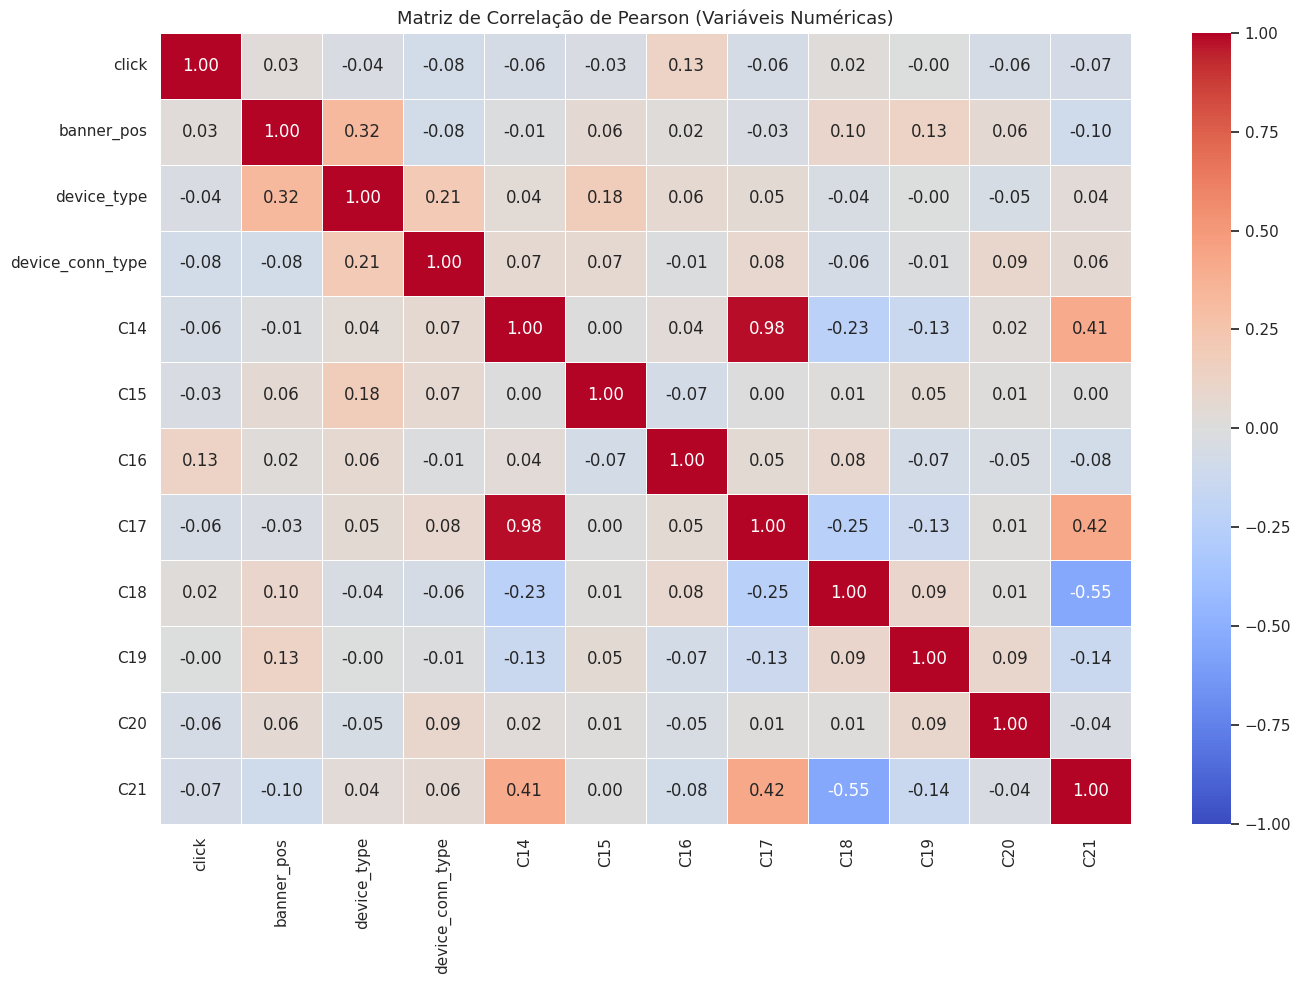

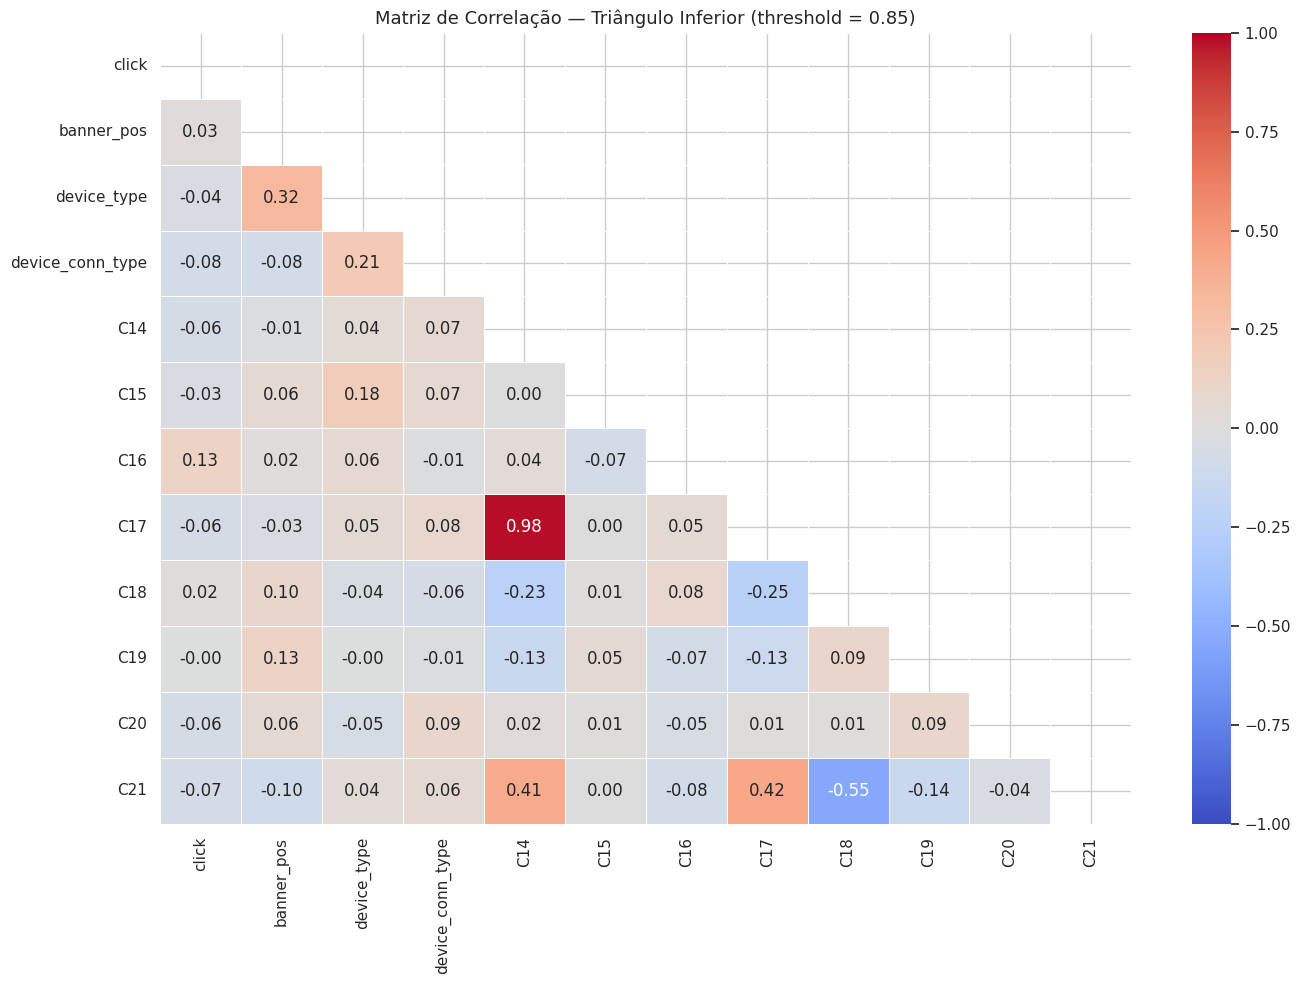

Correlações com a variável alvo ('click'):
  C16                      : +0.1303
  device_conn_type         : -0.0832
  C21                      : -0.0698
  C14                      : -0.0608
  C20                      : -0.0580
  C17                      : -0.0561
  device_type              : -0.0374
  C15                      : -0.0325
  banner_pos               : +0.0263
  C18                      : +0.0216
  C19                      : -0.0038

Pares com |correlação| > 0.85 (multicolinearidade):
  C14  ↔  C17  →  r = 0.9769


,Var A,Var B,r
0,C14,C17,0.9769


In [10]:
#  Análise de correlações entre variáveis numéricas
sns.set_theme(style='whitegrid')

# Conjunto de variáveis a incluir na matriz. Incluímos `click` para ver
# diretamente a correlação (linear) de cada feature com a variável alvo.
# Excluímos as colunas puramente categóricas (site_id, app_id, ...) por não
# serem significativas em correlação de Pearson antes do encoding.
cols_to_correlate = ['click', 'banner_pos', 'device_type', 'device_conn_type',
                     'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21']

# Matriz de correlação de Pearson (linear) entre todas as colunas selecionadas
corr_df = df[cols_to_correlate].corr()

# ── Visualização 1: heatmap completo ──────────────────────────────
# Mostra a matriz inteira (inclui redundância entre triângulo superior/inferior).
plt.figure(figsize=(14, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlação de Pearson (Variáveis Numéricas)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Visualização 2: heatmap triangular (sem duplicados) ───────────
# np.triu cria uma máscara para esconder o triângulo superior, que é redundante
# por simetria (Corr(A,B) = Corr(B,A)).
mask = np.triu(np.ones_like(corr_df.values, dtype=bool))
plt.figure(figsize=(14, 10))
sns.heatmap(corr_df, mask=mask, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.4, vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlação — Triângulo Inferior (threshold = 0.85)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Interpretação 1: correlações com a variável alvo ──────────────
# Ordenadas por valor absoluto (relevância, não sinal).
print("Correlações com a variável alvo ('click'):")
corr_alvo = corr_df['click'].drop('click').sort_values(key=abs, ascending=False)
for col, val in corr_alvo.items():
    print(f"  {col:<25}: {val:+.4f}")

# ── Interpretação 2: deteção de multicolinearidade ────────────────
# Pares com |correlação| > 0.85 são candidatos a remoção no pré-processamento,
# pois introduzem redundância informativa e podem instabilizar regressões.
THRESHOLD = 0.85
print(f"\nPares com |correlação| > {THRESHOLD} (multicolinearidade):")
pares = []
cols_list = list(corr_df.columns)
for i in range(len(cols_list)):
    for j in range(i+1, len(cols_list)):
        r = corr_df.iloc[i, j]
        if abs(r) > THRESHOLD:
            pares.append({'Var A': cols_list[i], 'Var B': cols_list[j], 'r': round(r, 4)})
            print(f"  {cols_list[i]}  ↔  {cols_list[j]}  →  r = {r:.4f}")
if not pares:
    print("  Nenhum par acima do threshold.")
else:
    display(pd.DataFrame(pares).sort_values('r', key=abs, ascending=False))


### 4.6 Análise Bivariada — CTR por Variável

Taxa de cliques (CTR) calculada directamente na amostra para as variáveis mais relevantes: hora do dia, posição do banner, tipo de dispositivo, tipo de ligação, categoria de site e categoria de app.

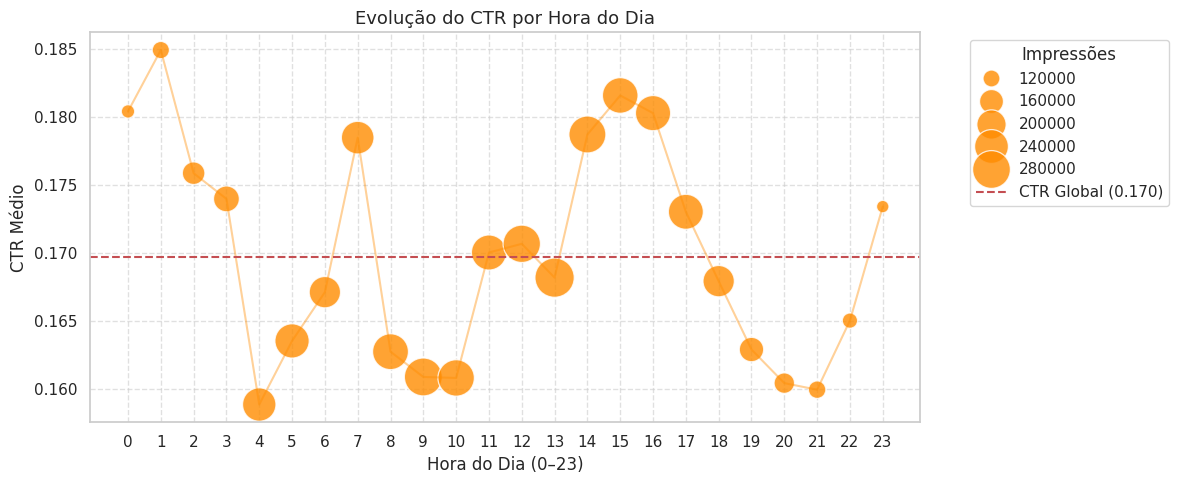

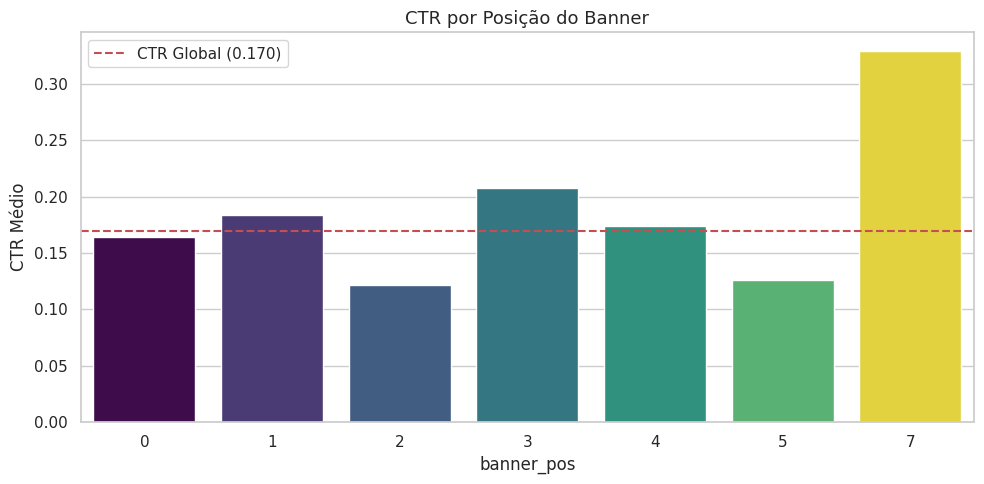

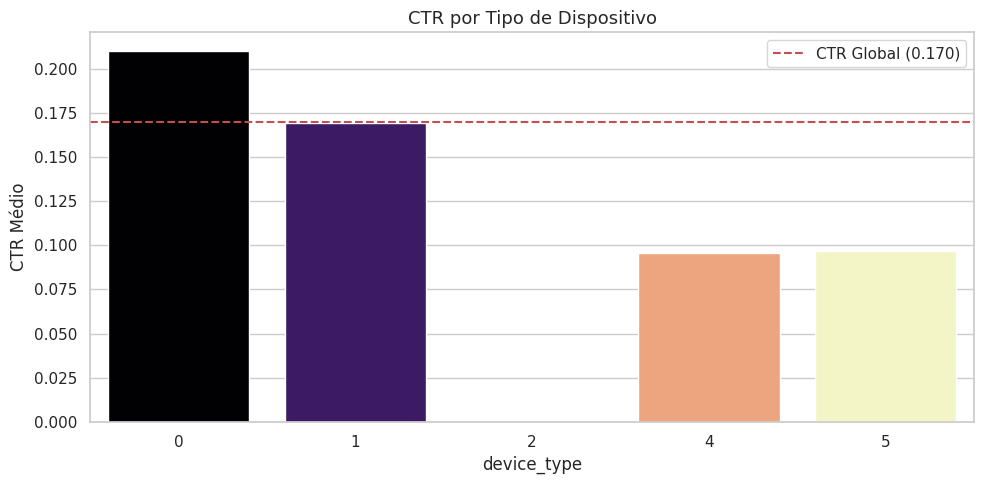

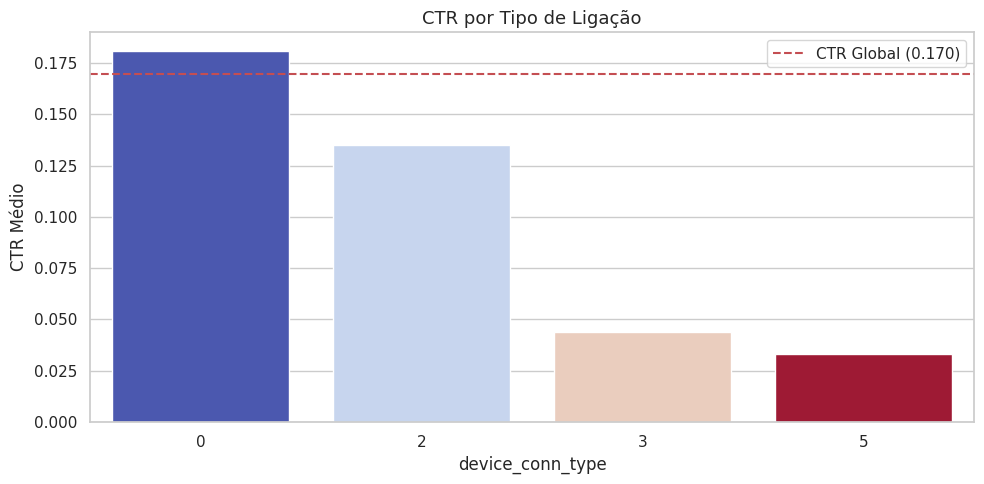

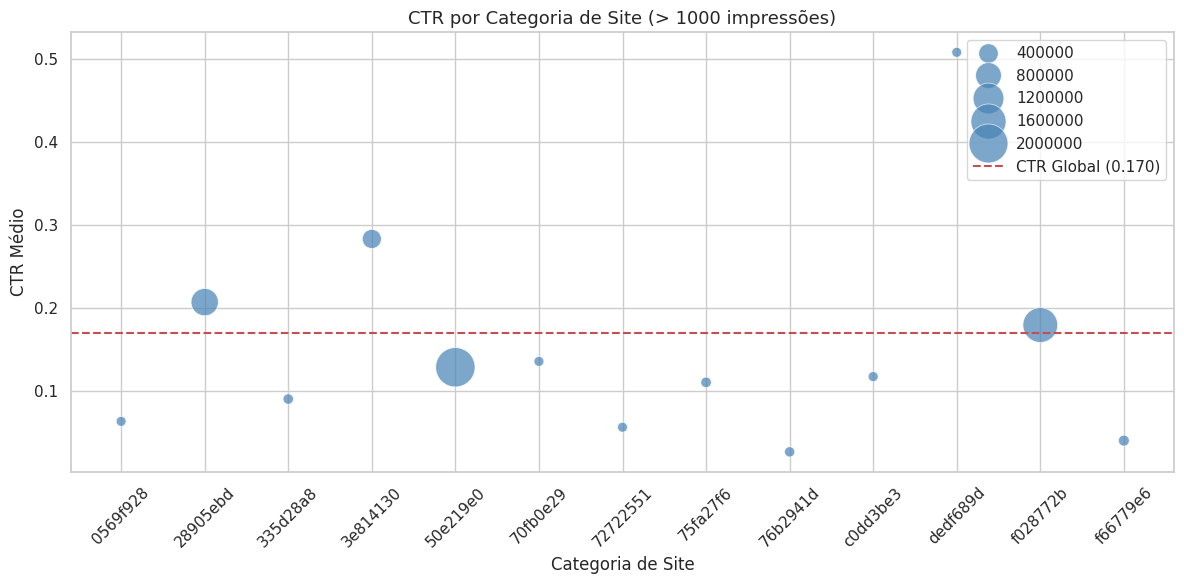

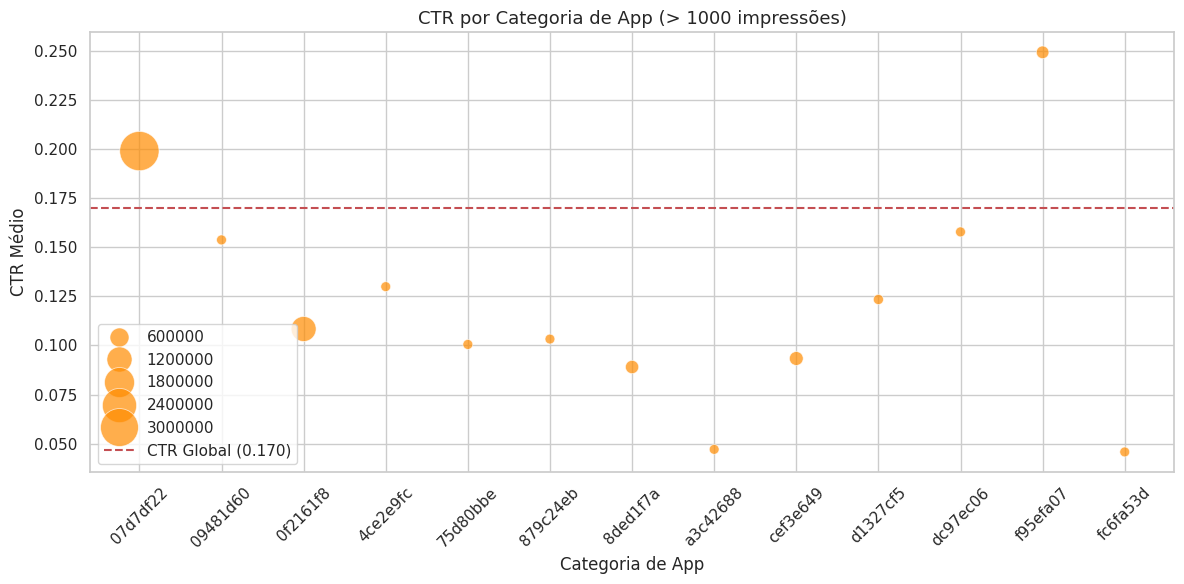

Análise bivariada CTR concluída.


In [11]:
# ── Preparar coluna hora_do_dia temporária ──────────────────
df_eda = df.copy()
df_eda['hora_do_dia'] = df_eda['hour'] % 100

global_ctr = df_eda['click'].mean()

def plot_ctr_bar(stats_df, x_col, title, palette='viridis'):
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=stats_df, x=x_col, y='CTR',
                     hue=x_col, palette=palette, legend=False)
    plt.axhline(global_ctr, color='r', linestyle='--',
                label=f'CTR Global ({global_ctr:.3f})')
    plt.title(title, fontsize=13)
    plt.xlabel(x_col)
    plt.ylabel('CTR Médio')
    plt.legend()
    plt.tight_layout()
    plt.show()

# ── CTR por Hora do Dia ─────────────────────────────────────
df_hour = df_eda.groupby('hora_do_dia')['click'].agg(
    clicks='sum', impressions='count').reset_index()
df_hour['CTR'] = df_hour['clicks'] / df_hour['impressions']
df_hour.sort_values('hora_do_dia', inplace=True)

plt.figure(figsize=(12, 5))
sns.scatterplot(data=df_hour, x='hora_do_dia', y='CTR',
                size='impressions', sizes=(80, 800), color='darkorange', alpha=0.8)
sns.lineplot(data=df_hour, x='hora_do_dia', y='CTR', color='darkorange', alpha=0.4)
plt.axhline(global_ctr, color='r', linestyle='--', label=f'CTR Global ({global_ctr:.3f})')
plt.title('Evolução do CTR por Hora do Dia', fontsize=13)
plt.xlabel('Hora do Dia (0–23)')
plt.ylabel('CTR Médio')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Impressões', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ── CTR por banner_pos ──────────────────────────────────────
df_banner = df_eda.groupby('banner_pos')['click'].agg(
    clicks='sum', impressions='count').reset_index()
df_banner['CTR'] = df_banner['clicks'] / df_banner['impressions']
plot_ctr_bar(df_banner, 'banner_pos', 'CTR por Posição do Banner', 'viridis')

# ── CTR por device_type ─────────────────────────────────────
df_dev = df_eda.groupby('device_type')['click'].agg(
    clicks='sum', impressions='count').reset_index()
df_dev['CTR'] = df_dev['clicks'] / df_dev['impressions']
plot_ctr_bar(df_dev, 'device_type', 'CTR por Tipo de Dispositivo', 'magma')

# ── CTR por device_conn_type ────────────────────────────────
df_conn = df_eda.groupby('device_conn_type')['click'].agg(
    clicks='sum', impressions='count').reset_index()
df_conn['CTR'] = df_conn['clicks'] / df_conn['impressions']
plot_ctr_bar(df_conn, 'device_conn_type', 'CTR por Tipo de Ligação', 'coolwarm')

# ── CTR por site_category ───────────────────────────────────
df_site = df_eda.groupby('site_category')['click'].agg(
    clicks='sum', impressions='count').reset_index()
df_site['CTR'] = df_site['clicks'] / df_site['impressions']
df_site = df_site[df_site['impressions'] > 1000]

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_site, x='site_category', y='CTR',
                size='impressions', sizes=(50, 800), alpha=0.7, color='steelblue')
plt.axhline(global_ctr, color='r', linestyle='--', label=f'CTR Global ({global_ctr:.3f})')
plt.title('CTR por Categoria de Site (> 1000 impressões)', fontsize=13)
plt.xlabel('Categoria de Site')
plt.ylabel('CTR Médio')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# ── CTR por app_category ────────────────────────────────────
df_app = df_eda.groupby('app_category')['click'].agg(
    clicks='sum', impressions='count').reset_index()
df_app['CTR'] = df_app['clicks'] / df_app['impressions']
df_app = df_app[df_app['impressions'] > 1000]

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_app, x='app_category', y='CTR',
                size='impressions', sizes=(50, 800), alpha=0.7, color='darkorange')
plt.axhline(global_ctr, color='r', linestyle='--', label=f'CTR Global ({global_ctr:.3f})')
plt.title('CTR por Categoria de App (> 1000 impressões)', fontsize=13)
plt.xlabel('Categoria de App')
plt.ylabel('CTR Médio')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

del df_eda
print('Análise bivariada CTR concluída.')

### 4.7 Missing Values Mascarados — Antes e Depois da Limpeza

Comparação visual do impacto da imputação por moda na coluna C20 (que usa -1 como código de valor em falta).

=== ANTES DA LIMPEZA ===
Valores -1 em C20: 2,344,248
Distribuição C20 (top 5):
C20
-1         2344248
 100084     301520
 100148     221366
 100111     212930
 100077     195121
Name: count, dtype: int64

=== DEPOIS DA LIMPEZA ===
Valores -1 em C20: 0
Distribuição C20 (top 5):
C20
100084    2645768
100148     221366
100111     212930
100077     195121
100075     191012
Name: count, dtype: int64



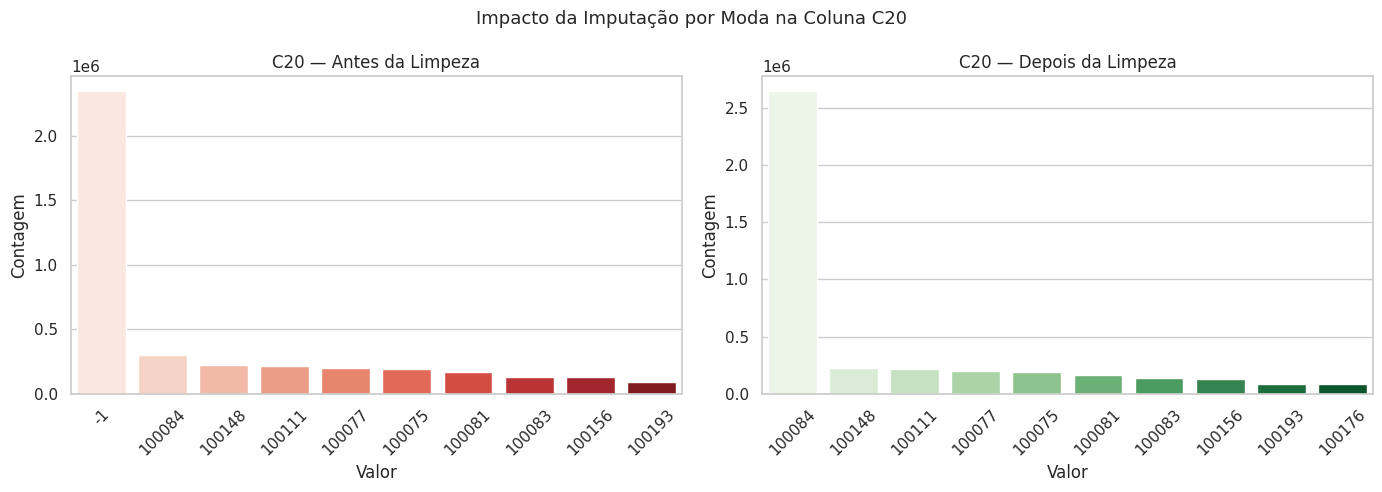

In [12]:
moda_c20 = df['C20'][df['C20'] != -1].mode()[0]

print('=== ANTES DA LIMPEZA ===')
print(f"Valores -1 em C20: {(df['C20'] == -1).sum():,}")
print(f"Distribuição C20 (top 5):\n{df['C20'].value_counts().head()}\n")

df_clean_demo = df.copy()
df_clean_demo['C20'] = df_clean_demo['C20'].replace(-1, pd.NA).fillna(moda_c20)

print('=== DEPOIS DA LIMPEZA ===')
print(f"Valores -1 em C20: {(df_clean_demo['C20'] == -1).sum():,}")
print(f"Distribuição C20 (top 5):\n{df_clean_demo['C20'].value_counts().head()}\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cb = df['C20'].value_counts().head(10)
sns.barplot(x=cb.index.astype(str), y=cb.values,
            hue=cb.index.astype(str), palette='Reds', ax=axes[0], legend=False)
axes[0].set_title('C20 — Antes da Limpeza')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Contagem')
axes[0].tick_params(axis='x', rotation=45)

ca = df_clean_demo['C20'].value_counts().head(10)
sns.barplot(x=ca.index.astype(str), y=ca.values,
            hue=ca.index.astype(str), palette='Greens', ax=axes[1], legend=False)
axes[1].set_title('C20 — Depois da Limpeza')
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Contagem')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Impacto da Imputação por Moda na Coluna C20', fontsize=13)
plt.tight_layout()
plt.show()
del df_clean_demo

## 5. Pré-Processamento e Feature Engineering

Criação de novas variáveis, imputação de missing values mascarados, Label Encoding das colunas categóricas, remoção de colunas com multicolinearidade elevada (|r| > 0.95) e verificação da correlação das novas features.

In [13]:

from sklearn.preprocessing import StandardScaler

df_proc = df.copy()

# Verificação das suposições sobre C15 e C16 
# Antes de criar banner_area, verificamos e documentamos a hipótese de que
# C15 e C16 representam, respetivamente, largura e altura do banner (em pixels).
# As colunas C14–C21 são anónimas no dataset Avazu, portanto esta é uma suposição
# que o leitor do notebook deve conhecer.
print('Valores únicos de C15:', sorted(df_proc['C15'].unique())[:15])
print('Valores únicos de C16:', sorted(df_proc['C16'].unique())[:15])
print("""
→ Se os valores forem compatíveis com dimensões típicas de banners em pixels
  (120, 216, 300, 320, 480, 728, 768, 1024, ...) a hipótese fica reforçada.
→ Caso contrário, banner_area deve ser interpretada apenas como a interação
  C15×C16, sem significado geométrico.
""")

#  IMPUTAÇÃO SISTEMÁTICA DE MISSING MASCARADOS
# Aqui, aplicamos o mesmo tratamento a todas as colunas C14–C21 em que a percentagem de -1 ultrapasse um threshold.
THRESHOLD_PCT = 1.0  # colunas com < 1% de -1 são consideradas limpas
print('Imputação por moda (substituindo -1) nas colunas com ≥ 1% de valores mascarados:')
for col in [f'C{i}' for i in range(14, 22)]:
    if col not in df_proc.columns:
        continue
    pct_neg = (df_proc[col] == -1).mean() * 100
    if pct_neg >= THRESHOLD_PCT:
        moda = int(df_proc[col][df_proc[col] != -1].mode()[0])
        df_proc[col] = df_proc[col].replace(-1, pd.NA).fillna(moda).astype(int)
        print(f'  {col}: {pct_neg:5.2f}% de -1 imputados pela moda ({moda})')
    else:
        print(f'  {col}: {pct_neg:5.2f}% de -1 — abaixo do threshold, sem imputação')

#  FEATURE ENGINEERING 
# hora_do_dia — extraída de 'hour' (formato YYMMDDhh)
df_proc['hora_do_dia'] = df_proc['hour'] % 100

# banner_area — largura × altura do banner (ver nota C15/C16 acima)
df_proc['banner_area'] = df_proc['C15'] * df_proc['C16']

# [CORRECAO 2.3] visibilidade_anuncio
# Versão original: banner_pos / log1p(banner_area) — problema: banner_pos é
# frequentemente 0 (posição 'top'), o que zera toda a feature para a maioria
# dos registos e destrói a sua variância. Usamos (banner_pos + 1) para preservar
# informação mesmo quando a posição é 0.
df_proc['visibilidade_anuncio'] = (df_proc['banner_pos'] + 1) / np.log1p(df_proc['banner_area'])
frac_zeros = (df_proc['visibilidade_anuncio'] == 0).mean() * 100
print(f"\n  Fracção de zeros em visibilidade_anuncio: {frac_zeros:.2f}%  (deve ser baixa)")

# Remover coluna 'hour' original
df_proc.drop(columns=['hour'], inplace=True)
print('\n  Features criadas: hora_do_dia, banner_area, visibilidade_anuncio')

#  CORRELAÇÃO DAS NOVAS VARIÁVEIS COM CLICK 
novas_vars = ['hora_do_dia', 'banner_area', 'visibilidade_anuncio']
print("\nCorrelação das novas variáveis com 'click':")
for v in novas_vars:
    r = df_proc[v].corr(df_proc['click'])
    print(f"  {v:<25}: {r:+.4f}")

# REMOVER COLUNAS NÃO PREDITIVAS 
cols_to_remove = ['id', 'device_id', 'device_ip']
df_proc.drop(columns=[c for c in cols_to_remove if c in df_proc.columns], inplace=True)
print(f'\n  Colunas removidas (não preditivas): {cols_to_remove}')

# Encoding de categóricas é feito APÓS o split.
# As colunas object permanecem como object até essa altura.
cat_pendentes = df_proc.select_dtypes(include='object').columns.tolist()
print(f'\n  Colunas categóricas pendentes de encoding (a fazer após split): {cat_pendentes}')


print(f'\nDataset intermédio: {df_proc.shape[0]:,} registos × {df_proc.shape[1]} colunas')
print('(Encoding + remoção de multicolinearidade ocorrem após o split.)')


Valores únicos de C15: [np.int64(120), np.int64(216), np.int64(300), np.int64(320), np.int64(480), np.int64(728), np.int64(768), np.int64(1024)]
Valores únicos de C16: [np.int64(20), np.int64(36), np.int64(50), np.int64(90), np.int64(250), np.int64(320), np.int64(480), np.int64(768), np.int64(1024)]

→ Se os valores forem compatíveis com dimensões típicas de banners em pixels
  (120, 216, 300, 320, 480, 728, 768, 1024, ...) a hipótese fica reforçada.
→ Caso contrário, banner_area deve ser interpretada apenas como a interação
  C15×C16, sem significado geométrico.

Imputação por moda (substituindo -1) nas colunas com ≥ 1% de valores mascarados:
  C14:  0.00% de -1 — abaixo do threshold, sem imputação
  C15:  0.00% de -1 — abaixo do threshold, sem imputação
  C16:  0.00% de -1 — abaixo do threshold, sem imputação
  C17:  0.00% de -1 — abaixo do threshold, sem imputação
  C18:  0.00% de -1 — abaixo do threshold, sem imputação
  C19:  0.00% de -1 — abaixo do threshold, sem imputação
  C20:

## 6. Inspeção do Dataset Processado

In [14]:

print('DIMENSÃO')
print(f'  {df_proc.shape[0]:,} registos × {df_proc.shape[1]} colunas')

print('\nPRIMEIRAS 5 LINHAS')
display(df_proc.head())

print('\nTIPOS DE DADOS')
display(df_proc.dtypes.to_frame('Tipo'))

print('\nVALORES NULOS')
nc = df_proc.isnull().sum()
display(nc.to_frame('Nulos'))
print(f'Total de valores nulos: {int(nc.sum())}')

print('\nESTATÍSTICAS NUMÉRICAS')
display(df_proc.describe())

DIMENSÃO
  5,000,000 registos × 23 colunas

PRIMEIRAS 5 LINHAS


,click,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_model,...,C15,C16,C17,C18,C19,C20,C21,hora_do_dia,banner_area,visibilidade_anuncio
0,0,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,8a4875bd,...,320,50,1722,0,35,100084,79,0,16000,0.103301
1,0,1002,0,84c7ba46,c4e18dd6,50e219e0,ecad2386,7801e8d9,07d7df22,373ecbe6,...,320,50,2496,3,167,100191,23,0,16000,0.103301
2,0,1005,0,543a539e,c7ca3108,3e814130,ecad2386,7801e8d9,07d7df22,607e78f2,...,320,50,2333,0,39,100084,157,0,16000,0.103301
3,1,1002,0,84c7ba46,c4e18dd6,50e219e0,ecad2386,7801e8d9,07d7df22,cf19f7f7,...,320,50,2446,3,171,100228,156,0,16000,0.103301
4,1,1005,0,85f751fd,c4e18dd6,50e219e0,0acbeaa3,45a51db4,f95efa07,68b900d9,...,320,50,2161,0,35,100034,157,0,16000,0.103301



TIPOS DE DADOS


,Tipo
click,int64
C1,int64
banner_pos,int64
site_id,object
site_domain,object
site_category,object
app_id,object
app_domain,object
app_category,object
device_model,object



VALORES NULOS


,Nulos
click,0
C1,0
banner_pos,0
site_id,0
site_domain,0
site_category,0
app_id,0
app_domain,0
app_category,0
device_model,0


Total de valores nulos: 0

ESTATÍSTICAS NUMÉRICAS


,click,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,hora_do_dia,banner_area,visibilidade_anuncio
count,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,1.697188e-01,1.004968e+03,2.881012e-01,1.015408e+00,3.300478e-01,1.884259e+04,3.188800e+02,6.005896e+01,2.112686e+03,1.432106e+00,2.272310e+02,1.000991e+05,8.340489e+01,1.127767e+01,1.908003e+04,1.322940e-01
std,3.753856e-01,1.095621e+00,5.057768e-01,5.279241e-01,8.530219e-01,4.958047e+03,2.123737e+01,4.722027e+01,6.092178e+02,1.326446e+00,3.510607e+02,3.973293e+01,7.029536e+01,5.954430e+00,1.624028e+04,5.072208e-02
min,0.000000e+00,1.001000e+03,0.000000e+00,0.000000e+00,0.000000e+00,3.750000e+02,1.200000e+02,2.000000e+01,1.120000e+02,0.000000e+00,3.300000e+01,1.000000e+05,1.000000e+00,0.000000e+00,2.400000e+03,7.366340e-02
25%,0.000000e+00,1.005000e+03,0.000000e+00,1.000000e+00,0.000000e+00,1.692000e+04,3.200000e+02,5.000000e+01,1.863000e+03,0.000000e+00,3.500000e+01,1.000840e+05,2.300000e+01,7.000000e+00,1.600000e+04,1.033014e-01
50%,0.000000e+00,1.005000e+03,0.000000e+00,1.000000e+00,0.000000e+00,2.034600e+04,3.200000e+02,5.000000e+01,2.323000e+03,2.000000e+00,3.900000e+01,1.000840e+05,6.100000e+01,1.100000e+01,1.600000e+04,1.033014e-01
75%,0.000000e+00,1.005000e+03,1.000000e+00,1.000000e+00,0.000000e+00,2.189400e+04,3.200000e+02,5.000000e+01,2.526000e+03,3.000000e+00,1.710000e+02,1.000880e+05,1.010000e+02,1.600000e+01,1.600000e+04,2.066029e-01
max,1.000000e+00,1.012000e+03,7.000000e+00,5.000000e+00,5.000000e+00,2.405200e+04,1.024000e+03,1.024000e+03,2.758000e+03,3.000000e+00,1.959000e+03,1.002480e+05,2.550000e+02,2.300000e+01,7.864320e+05,8.264116e-01


**Feito por: Bernardo e Hugo**

In [15]:
df_amostra_final = df_proc.head(15)
nome_ficheiro = '/kaggle/working/processado_15_linhas.csv'
df_amostra_final.to_csv(nome_ficheiro, index=False)
print(f" Ficheiro '{nome_ficheiro}' guardado.")
print(f"   Dimensão: {df_amostra_final.shape[0]} linhas × {df_amostra_final.shape[1]} colunas")

 Ficheiro '/kaggle/working/processado_15_linhas.csv' guardado.
   Dimensão: 15 linhas × 23 colunas


In [16]:
output_path = '/kaggle/working/train_processed.csv'
df_proc.to_csv(output_path, index=False)
print(f' Dataset processado guardado em: {output_path}')
print(f'   {df_proc.shape[0]:,} registos × {df_proc.shape[1]} colunas')
print('Pipeline completo — dataset pronto para modelação.')

 Dataset processado guardado em: /kaggle/working/train_processed.csv
   5,000,000 registos × 23 colunas
Pipeline completo — dataset pronto para modelação.



# MILESTONE 3 — MODELAÇÃO E AVALIAÇÃO



## Metodologia de Avaliação e Partição de Dados

### Ponto C — Fundamentação da Estratégia de Métricas

O problema é de **classificação binária supervisionada** (prever se um utilizador clica num anúncio).
O dataset apresenta um forte desequilíbrio de classes (~17% de cliques vs. ~83% de não-cliques).

#### Por que AUC-ROC como métrica principal?
- É a **métrica oficial** da competição Avazu CTR Prediction (He et al., 2014).
- Mede a capacidade de **ordenar** anúncios por probabilidade de clique, independentemente do threshold de decisão.
- É **robusta ao desequilíbrio**: um modelo que prevê sempre 0 tem AUC-ROC = 0.5 (sem valor), enquanto a Accuracy seria enganosamente 83% — fenómeno conhecido como *accuracy paradox* (Japkowicz & Stephen, 2002).
- No contexto de RTB (*Real-Time Bidding*), o modelo não é utilizado com um único threshold fixo, mas sim para ordenar e licitar anúncios — por isso importa a capacidade de ranking, não um limiar binário.

#### Por que F1-Score como métrica secundária?
- Um **Falso Negativo** (não prever um clique real) representa receita publicitária perdida para o anunciante.
- Um **Falso Positivo** (prever clique quando não há) representa custo desperdiçado por impressão inútil.
- O F1 equilibra Precisão e Recall, penalizando ambos os tipos de erro — essencial num contexto de negócio onde os dois erros têm consequências financeiras.

#### Por que excluímos a Accuracy?
- Um modelo que previsse sempre `click=0` teria **83% de Accuracy** sem qualquer valor preditivo — métrica completamente enganosa em dados desequilibrados.

#### Isolamento rigoroso dos dados — prevenção de *data leakage*
- Divisão estratificada **80/20** com `random_state=42`, garantindo a proporção de cliques em ambos os conjuntos.
- O scaler (`StandardScaler`) é ajustado **exclusivamente** no conjunto de treino (`fit_transform`) e aplicado ao teste (`transform`) — nunca o contrário.
- Os dados de teste **nunca** são vistos durante o treino ou o tuning — garantia absoluta de ausência de *data leakage*.
- A Cross-Validation na Aula 19 é aplicada **dentro do conjunto de treino**, mantendo o conjunto de teste completamente isolado até à avaliação final.

In [17]:
from sklearn.model_selection import train_test_split

X = df_proc.drop(columns=['click'])
y = df_proc['click']

# Divisão estratificada 80/20 — preserva proporção de cliques
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y   # garante mesma proporção de cliques em treino e teste
)

print(f'Treino : {X_train.shape[0]:,} registos ({X_train.shape[0]/len(df_proc)*100:.0f}%)')
print(f'Teste  : {X_test.shape[0]:,} registos ({X_test.shape[0]/len(df_proc)*100:.0f}%)')
print(f'\nProporção de cliques no treino : {y_train.mean():.4f}')
print(f'Proporção de cliques no teste  : {y_test.mean():.4f}')
print('\nProporções consistentes — divisão estratificada correcta.')
print('   Isolamento garantido: X_test nunca será visto durante o treino nem o tuning.')
print('\n  ATENÇÃO: X_train e X_test contêm ainda colunas categóricas (object).')
print('            O encoding é feito na próxima célula, usando apenas informação do TREINO.')


Treino : 4,000,000 registos (80%)
Teste  : 1,000,000 registos (20%)

Proporção de cliques no treino : 0.1697
Proporção de cliques no teste  : 0.1697

Proporções consistentes — divisão estratificada correcta.
   Isolamento garantido: X_test nunca será visto durante o treino nem o tuning.

  ATENÇÃO: X_train e X_test contêm ainda colunas categóricas (object).
            O encoding é feito na próxima célula, usando apenas informação do TREINO.


In [18]:
#  FREQUENCY ENCODING SEM DATA LEAKAGE 
cols_categoricas = X_train.select_dtypes(include='object').columns.tolist()
print(f'Colunas a codificar ({len(cols_categoricas)}): {cols_categoricas}\n')

for col in cols_categoricas:
    # Frequência relativa calculada APENAS no treino
    freq_map = X_train[col].value_counts(normalize=True).to_dict()

    # Aplicar ao treino e ao teste (teste: categorias novas -> 0)
    X_train[col] = X_train[col].map(freq_map).astype(float)
    X_test[col]  = X_test[col].map(freq_map).fillna(0.0).astype(float)

    print(f'  {col:<18} -> {len(freq_map):>6} categorias únicas no treino')

print('\nTipos após encoding (X_train):')
print(X_train.dtypes.value_counts())
print('\n  Sem data leakage: freq_map construído EXCLUSIVAMENTE com X_train.')
print('  Sem falsa ordinalidade: as novas features representam prevalência, não ordem.')

#  Deteção e remoção de multicolinearidade (> 0.95)
print('Verificação de multicolinearidade no conjunto de TREINO:')
corr_train = X_train.corr().abs()
upper = corr_train.where(np.triu(np.ones(corr_train.shape), k=1).astype(bool))
cols_multi = [col for col in upper.columns if any(upper[col] > 0.95)]

if cols_multi:
    print(f'  Colunas com |r| > 0.95: {cols_multi}')
    X_train.drop(columns=cols_multi, inplace=True)
    X_test.drop(columns=cols_multi, inplace=True)
    print(f'    {len(cols_multi)} coluna(s) removida(s) de AMBOS os conjuntos.')
else:
    print('  Nenhuma coluna com |r| > 0.95 — sem remoções.')

print(f'\nShape final:  X_train {X_train.shape}  |  X_test {X_test.shape}')


Colunas a codificar (7): ['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_model']

  site_id            ->   3414 categorias únicas no treino
  site_domain        ->   4274 categorias únicas no treino
  site_category      ->     22 categorias únicas no treino
  app_id             ->   4929 categorias únicas no treino
  app_domain         ->    318 categorias únicas no treino
  app_category       ->     30 categorias únicas no treino
  device_model       ->   6343 categorias únicas no treino

Tipos após encoding (X_train):
int64      14
float64     8
Name: count, dtype: int64

  Sem data leakage: freq_map construído EXCLUSIVAMENTE com X_train.
  Sem falsa ordinalidade: as novas features representam prevalência, não ordem.
Verificação de multicolinearidade no conjunto de TREINO:
  Colunas com |r| > 0.95: ['site_domain', 'app_category', 'C17', 'visibilidade_anuncio']
    4 coluna(s) removida(s) de AMBOS os conjuntos.

Shape final:  X_train (40000

### Definição das Métricas de Avaliação

Função reutilizável para todas as experiências do Milestone 3. Calcula AUC-ROC, F1-Score, Precisão e Recall de forma consistente, com diagnóstico automático de overfitting/underfitting.

In [19]:
import time
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

def avaliar_completo(modelo, X_tr, y_tr, X_te, y_te, nome, scaler=None):
    """
    Avalia um modelo em treino e teste, devolvendo dicionário com todas as métricas.
    Se scaler não for None, aplica a transformação antes da previsão.
    """
    if scaler is not None:
        X_tr_eval = scaler.transform(X_tr)
        X_te_eval = scaler.transform(X_te)
    else:
        X_tr_eval = X_tr
        X_te_eval = X_te

    # Treino
    y_pred_tr  = modelo.predict(X_tr_eval)
    y_proba_tr = modelo.predict_proba(X_tr_eval)[:, 1]
    # Teste
    y_pred_te  = modelo.predict(X_te_eval)
    y_proba_te = modelo.predict_proba(X_te_eval)[:, 1]

    resultados = {
        'Modelo':              nome,
        'AUC-ROC (Treino)':   round(roc_auc_score(y_tr, y_proba_tr), 4),
        'AUC-ROC (Teste)':    round(roc_auc_score(y_te, y_proba_te), 4),
        'F1 (Treino)':        round(f1_score(y_tr, y_pred_tr), 4),
        'F1 (Teste)':         round(f1_score(y_te, y_pred_te), 4),
        'Precisão (Teste)':   round(precision_score(y_te, y_pred_te), 4),
        'Recall (Teste)':     round(recall_score(y_te, y_pred_te), 4),
    }

    print(f"\n{'='*55}  {nome}")
    print(f"  AUC-ROC  Treino: {resultados['AUC-ROC (Treino)']:.4f}  |  Teste: {resultados['AUC-ROC (Teste)']:.4f}  ← principal")
    print(f"  F1-Score Treino: {resultados['F1 (Treino)']:.4f}  |  Teste: {resultados['F1 (Teste)']:.4f}")
    print(f"  Precisão (Teste): {resultados['Precisão (Teste)']:.4f}")
    print(f"  Recall   (Teste): {resultados['Recall (Teste)']:.4f}")

    delta = resultados['AUC-ROC (Treino)'] - resultados['AUC-ROC (Teste)']
    if delta > 0.05:
        print(f"    Possível Overfitting (Δ AUC = {delta:.4f}) — modelo memoriza o treino")
    elif resultados['AUC-ROC (Teste)'] < 0.60:
        print(f"    Possível Underfitting (AUC Teste = {resultados['AUC-ROC (Teste)']:.4f}) — modelo demasiado simples")
    else:
        print(f"   Generalização adequada (Δ AUC = {delta:.4f})")

    return resultados

resultados_todos = []
print(' Função avaliar_completo definida — pronta para uso em todas as aulas.')

 Função avaliar_completo definida — pronta para uso em todas as aulas.



## Implementação e Avaliação do Modelo Baseline

### Fundamentação da escolha do Baseline

A **Regressão Logística** foi escolhida como modelo de referência por ser o modelo de classificação linear mais simples e bem estabelecido (Cox, 1958). Em problemas de CTR, serve como *sanity check*: se um modelo complexo não superar significativamente a Regressão Logística, o custo computacional adicional não se justifica.

**Características que a tornam um Baseline ideal:**
- Baixa complexidade e alta interpretabilidade — permite compreender a direção e magnitude do efeito de cada feature
- Produz probabilidades calibradas nativamente — adequado para AUC-ROC
- Sem risco de overfitting severo — estabelece o patamar mínimo honesto
- Requer escalonamento (`StandardScaler`) para convergência estável

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Escalonamento (necessário para Regressão Logística)
# IMPORTANTE: fit apenas no treino para evitar data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform no treino
X_test_scaled  = scaler.transform(X_test)        # apenas transform no teste

print(' StandardScaler ajustado EXCLUSIVAMENTE no conjunto de treino.')
print('   Garante isolamento total: o teste não influenciou a normalização.\n')

# Treino do Baseline
print('A treinar Regressão Logística (Baseline)...')
t0 = time.time()
baseline = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # compensa o desequilíbrio 17/83
)
baseline.fit(X_train_scaled, y_train)
t_baseline = time.time() - t0
print(f'Baseline treinado em {t_baseline:.1f}s')

# Avaliação
res_baseline = avaliar_completo(
    baseline, X_train_scaled, y_train,
    X_test_scaled, y_test,
    'Regressão Logística (Baseline)'
)
resultados_todos.append(res_baseline)

 StandardScaler ajustado EXCLUSIVAMENTE no conjunto de treino.
   Garante isolamento total: o teste não influenciou a normalização.

A treinar Regressão Logística (Baseline)...
Baseline treinado em 18.6s

=======================================================  Regressão Logística (Baseline)
  AUC-ROC  Treino: 0.6411  |  Teste: 0.6412  ← principal
  F1-Score Treino: 0.3362  |  Teste: 0.3363
  Precisão (Teste): 0.2325
  Recall   (Teste): 0.6073
   Generalização adequada (Δ AUC = -0.0001)



## Treino e Avaliação Comparativa dos Modelos Candidatos

Selecionados dois algoritmos de ensemble learning de maior complexidade para superar o baseline:

1. **Random Forest** — ensemble de árvores de decisão com bagging; robusto a outliers e desequilíbrios; produz probabilidades bem calibradas; interpreta a importância de features diretamente.
2. **XGBoost** (Gradient Boosting) — estado da arte em competições de CTR; aprende iterativamente os erros dos modelos anteriores; superior em dados tabulares desequilibrados; `scale_pos_weight` compensa o desequilíbrio de classes.

Ambos testados com parâmetros base nesta aula. A otimização de hiperparâmetros ocorre na Aula 19.

In [21]:
#  Modelo 1: Random Forest
# Ensemble de árvores de decisão treinadas com bootstrap (bagging).
# Cada árvore vê uma amostra diferente dos dados e um subconjunto aleatório
# de features em cada split, o que reduz a correlação entre árvores e baixa
# a variância do modelo final (relativamente a uma árvore única).
#
# Parâmetros escolhidos:
#   - n_estimators=100: 100 árvores é um bom compromisso entre qualidade
#                       e tempo de treino com 4M linhas.
#   - max_depth=10:     limita a profundidade para controlar overfitting
#                       (árvores totalmente desenvolvidas memorizariam o treino).
#   - class_weight='balanced': compensa o desequilíbrio 17/83 ajustando o peso
#                              das classes inversamente à sua frequência.
#   - n_jobs=-1:        usa todos os cores disponíveis para paralelização.
#   - random_state=42:  reprodutibilidade.
from sklearn.ensemble import RandomForestClassifier

print('A treinar Random Forest...')
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_train, y_train)
t_rf = time.time() - t0
print(f' Random Forest treinado em {t_rf:.1f}s')

# Avaliação com a função utilitária definida na Aula 15
res_rf = avaliar_completo(rf, X_train, y_train, X_test, y_test, 'Random Forest')
resultados_todos.append(res_rf)


A treinar Random Forest...
 Random Forest treinado em 251.0s

=======================================================  Random Forest
  AUC-ROC  Treino: 0.7231  |  Teste: 0.7218  ← principal
  F1-Score Treino: 0.3946  |  Teste: 0.3938
  Precisão (Teste): 0.2739
  Recall   (Teste): 0.7000
   Generalização adequada (Δ AUC = 0.0013)


In [22]:
# Modelo 2: XGBoost
try:
    from xgboost import XGBClassifier
    xgb_disponivel = True
except ImportError:
    xgb_disponivel = False
    print('XGBoost não disponível — a usar GradientBoostingClassifier como alternativa.')

if xgb_disponivel:
    scale_pos_weight = int(np.sum(y_train == 0) / np.sum(y_train == 1))
    print(f'A treinar XGBoost (scale_pos_weight={scale_pos_weight})...')
    t0 = time.time()
    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,  # compensa o desequilíbrio 1:~5
        eval_metric='auc',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    xgb.fit(X_train, y_train)
    t_xgb = time.time() - t0
    print(f' XGBoost treinado em {t_xgb:.1f}s')
    res_xgb = avaliar_completo(xgb, X_train, y_train, X_test, y_test, 'XGBoost')
    resultados_todos.append(res_xgb)
    gbc = None
else:
    from sklearn.ensemble import GradientBoostingClassifier
    print('A treinar GradientBoosting...')
    t0 = time.time()
    gbc = GradientBoostingClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
    )
    gbc.fit(X_train, y_train)
    t_xgb = time.time() - t0
    print(f' GradientBoosting treinado em {t_xgb:.1f}s')
    res_xgb = avaliar_completo(gbc, X_train, y_train, X_test, y_test, 'GradientBoosting')
    resultados_todos.append(res_xgb)
    xgb = None


A treinar XGBoost (scale_pos_weight=4)...
 XGBoost treinado em 43.0s

=======================================================  XGBoost
  AUC-ROC  Treino: 0.7436  |  Teste: 0.7419  ← principal
  F1-Score Treino: 0.4168  |  Teste: 0.4157
  Precisão (Teste): 0.3054
  Recall   (Teste): 0.6510
   Generalização adequada (Δ AUC = 0.0017)


In [23]:
#  Seleção dinâmica do melhor candidato
auc_rf  = res_rf['AUC-ROC (Teste)']
auc_xgb = res_xgb['AUC-ROC (Teste)']

print('Comparação dos candidatos (AUC-ROC no conjunto de TESTE):')
print(f'   Random Forest                    : {auc_rf:.4f}')
print(f'   {"XGBoost" if xgb_disponivel else "GradientBoosting":<33}: {auc_xgb:.4f}')

if auc_rf > auc_xgb:
    melhor_candidato = rf
    melhor_candidato_nome = 'Random Forest'
else:
    melhor_candidato = xgb if xgb_disponivel else gbc
    melhor_candidato_nome = 'XGBoost' if xgb_disponivel else 'GradientBoosting'

print(f'\n  Melhor candidato: {melhor_candidato_nome}')
print(f'   → avança para a Aula 19 (otimização de hiperparâmetros)')


Comparação dos candidatos (AUC-ROC no conjunto de TESTE):
   Random Forest                    : 0.7218
   XGBoost                          : 0.7419

  Melhor candidato: XGBoost
   → avança para a Aula 19 (otimização de hiperparâmetros)


### Tabela Comparativa — Treino vs. Teste (todos os modelos)

TABELA COMPARATIVA — MÉTRICAS DE TREINO vs. TESTE


,AUC-ROC (Treino),AUC-ROC (Teste),F1 (Treino),F1 (Teste),Precisão (Teste),Recall (Teste),Δ AUC (Overfitting?)
Modelo,,,,,,,
Regressão Logística (Baseline),0.6411,0.6412,0.3362,0.3363,0.2325,0.6073,-0.0001
Random Forest,0.7231,0.7218,0.3946,0.3938,0.2739,0.7000,0.0013
XGBoost,0.7436,0.7419,0.4168,0.4157,0.3054,0.6510,0.0017


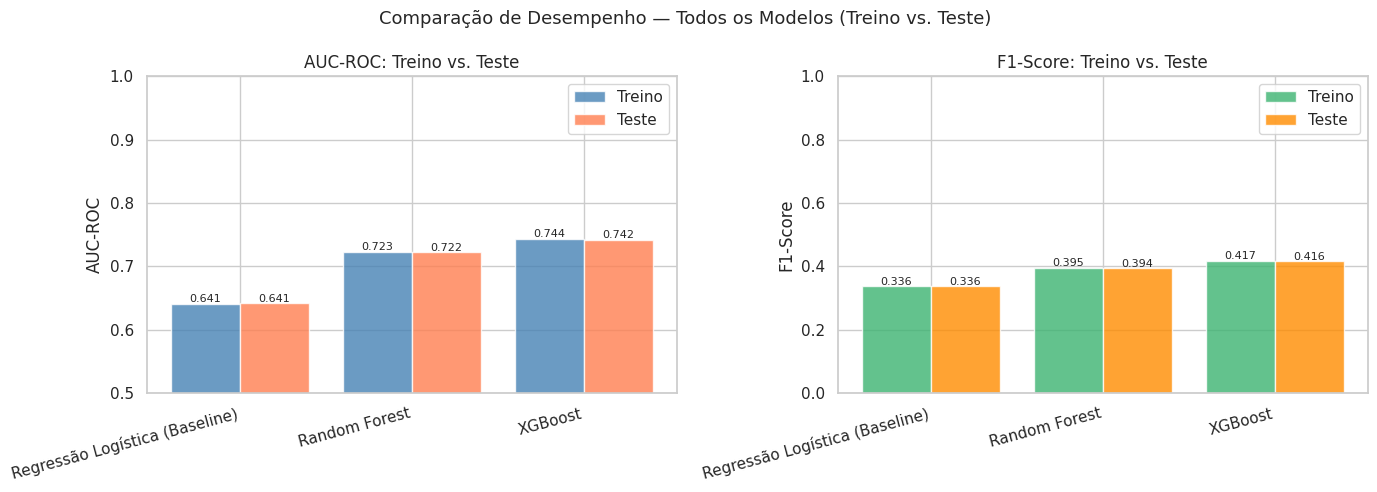


 Melhor modelo até ao momento: XGBoost (AUC-ROC Teste = 0.7419)
   → Este modelo avança para a fase de otimização de hiperparâmetros.


In [24]:
# Tabela Comparativa Treino vs. Teste 
df_resultados = pd.DataFrame(resultados_todos)
df_resultados['Δ AUC (Overfitting?)'] = (
    df_resultados['AUC-ROC (Treino)'] - df_resultados['AUC-ROC (Teste)']
).round(4)


print('TABELA COMPARATIVA — MÉTRICAS DE TREINO vs. TESTE')

display(df_resultados.set_index('Modelo'))

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos    = df_resultados['Modelo'].tolist()
auc_treino = df_resultados['AUC-ROC (Treino)'].tolist()
auc_teste  = df_resultados['AUC-ROC (Teste)'].tolist()
x = range(len(modelos))

axes[0].bar([i - 0.2 for i in x], auc_treino, 0.4, label='Treino', color='steelblue', alpha=0.8)
axes[0].bar([i + 0.2 for i in x], auc_teste,  0.4, label='Teste',  color='coral',     alpha=0.8)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(modelos, rotation=15, ha='right')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('AUC-ROC: Treino vs. Teste')
axes[0].legend()
axes[0].set_ylim(0.5, 1.0)
for i, (tr, te) in enumerate(zip(auc_treino, auc_teste)):
    axes[0].annotate(f'{tr:.3f}', (i - 0.2, tr + 0.002), ha='center', fontsize=8)
    axes[0].annotate(f'{te:.3f}', (i + 0.2, te + 0.002), ha='center', fontsize=8)

f1_treino = df_resultados['F1 (Treino)'].tolist()
f1_teste  = df_resultados['F1 (Teste)'].tolist()
axes[1].bar([i - 0.2 for i in x], f1_treino, 0.4, label='Treino', color='mediumseagreen', alpha=0.8)
axes[1].bar([i + 0.2 for i in x], f1_teste,  0.4, label='Teste',  color='darkorange',    alpha=0.8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(modelos, rotation=15, ha='right')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score: Treino vs. Teste')
axes[1].legend()
axes[1].set_ylim(0.0, 1.0)
for i, (tr, te) in enumerate(zip(f1_treino, f1_teste)):
    axes[1].annotate(f'{tr:.3f}', (i - 0.2, tr + 0.005), ha='center', fontsize=8)
    axes[1].annotate(f'{te:.3f}', (i + 0.2, te + 0.005), ha='center', fontsize=8)

plt.suptitle('Comparação de Desempenho — Todos os Modelos (Treino vs. Teste)', fontsize=13)
plt.tight_layout()
plt.show()

# Identificar o melhor modelo
melhor_idx  = df_resultados['AUC-ROC (Teste)'].idxmax()
melhor_nome = df_resultados.loc[melhor_idx, 'Modelo']
melhor_auc  = df_resultados.loc[melhor_idx, 'AUC-ROC (Teste)']
print(f'\n Melhor modelo até ao momento: {melhor_nome} (AUC-ROC Teste = {melhor_auc:.4f})')
print('   → Este modelo avança para a fase de otimização de hiperparâmetros.')

---
## Diagnóstico de Modelos e Generalização

### Curvas de Aprendizagem (*Learning Curves*)

As curvas de aprendizagem mostram como o desempenho dos modelos evolui com o número de exemplos de treino. Permitem diagnosticar:
- **Overfitting**: curva de treino muito acima da curva de validação — o modelo memoriza o treino mas não generaliza
- **Underfitting**: ambas as curvas baixas — o modelo é demasiado simples para capturar os padrões
- **Boa generalização**: ambas as curvas convergem para um valor elevado

Geradas usando validação cruzada estratificada com 3 *folds* para eficiência computacional.

A gerar curva de aprendizagem — Regressão Logística...


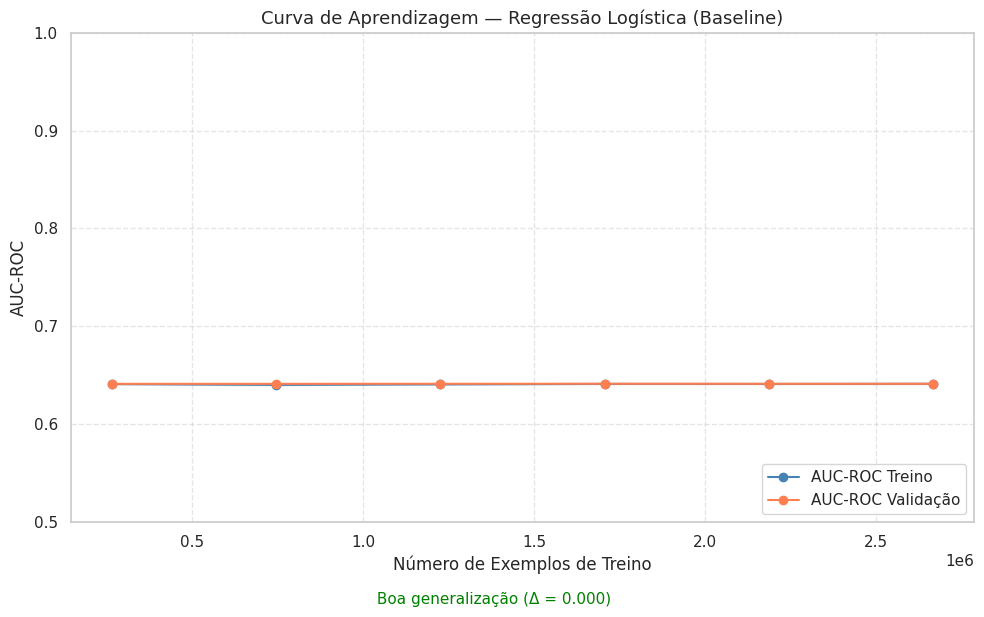

   Guardado: /kaggle/working/figures/learning_curve_regressão_logística_baseline.png
    Boa generalização (Δ = 0.000)


(array([ 266666,  746666, 1226666, 1706666, 2186666, 2666666]),
 array([0.64087741, 0.63998365, 0.64052399, 0.64098456, 0.64092917,
        0.64111136]),
 array([0.6410207 , 0.64105097, 0.64112601, 0.64114181, 0.64109009,
        0.64108929]))

In [25]:
from sklearn.model_selection import learning_curve
import os

#  Variável única para o diretório das figuras —
# evita a inconsistência entre "/kaggle/working/figures" (no código)
# e "reports/figures" (no sumário final).
FIGURES_DIR = '/kaggle/working/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

def plotar_curva_aprendizagem(modelo, X, y, nome, cv=3, n_jobs=-1,
                               train_sizes=np.linspace(0.1, 1.0, 6),
                               scaler=None):
    """
    Gera e plota a curva de aprendizagem de um modelo.
    Salva a figura em FIGURES_DIR para exportação.
    """
    if scaler is not None:
        from sklearn.pipeline import Pipeline
        from sklearn.base import clone
        from sklearn.preprocessing import StandardScaler as SS
        pipeline = Pipeline([('scaler', SS()), ('modelo', clone(modelo))])
        X_input = X
    else:
        pipeline = modelo
        X_input = X

    train_sz, train_scores, val_scores = learning_curve(
        pipeline, X_input, y,
        cv=cv,
        n_jobs=n_jobs,
        train_sizes=train_sizes,
        scoring='roc_auc',
        random_state=42
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores, axis=1)
    val_mean   = np.mean(val_scores, axis=1)
    val_std    = np.std(val_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sz, train_mean, 'o-', color='steelblue', label='AUC-ROC Treino')
    plt.fill_between(train_sz, train_mean - train_std, train_mean + train_std,
                     alpha=0.15, color='steelblue')
    plt.plot(train_sz, val_mean, 'o-', color='coral', label='AUC-ROC Validação')
    plt.fill_between(train_sz, val_mean - val_std, val_mean + val_std,
                     alpha=0.15, color='coral')
    plt.xlabel('Número de Exemplos de Treino')
    plt.ylabel('AUC-ROC')
    plt.title(f'Curva de Aprendizagem — {nome}', fontsize=13)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.ylim(0.5, 1.0)
    plt.tight_layout()

    # Diagnóstico automático
    delta_final = train_mean[-1] - val_mean[-1]
    if delta_final > 0.05:
        diagnostico = f'  OVERFITTING detectado (Δ = {delta_final:.3f})'
    elif val_mean[-1] < 0.60:
        diagnostico = f'  UNDERFITTING detectado (AUC Val = {val_mean[-1]:.3f})'
    else:
        diagnostico = f' Boa generalização (Δ = {delta_final:.3f})'
        
    cor_diag = 'red' if ('OVERFITTING' in diagnostico or 'UNDERFITTING' in diagnostico) else 'green'
    plt.figtext(0.5, -0.02, diagnostico, ha='center', fontsize=11, color=cor_diag)

    # FIGURES_DIR
    nome_ficheiro = nome.lower().replace(' ', '_').replace('(', '').replace(')', '')
    fig_path = f"{FIGURES_DIR}/learning_curve_{nome_ficheiro}.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'   Guardado: {fig_path}')
    print(f'   {diagnostico}')
    return train_sz, train_mean, val_mean

# ── Curva: Baseline (Regressão Logística) ───────────────────
print('A gerar curva de aprendizagem — Regressão Logística...')
plotar_curva_aprendizagem(
    baseline, X_train_scaled, y_train,
    'Regressão Logística (Baseline)'
)


A gerar curva de aprendizagem — Random Forest...


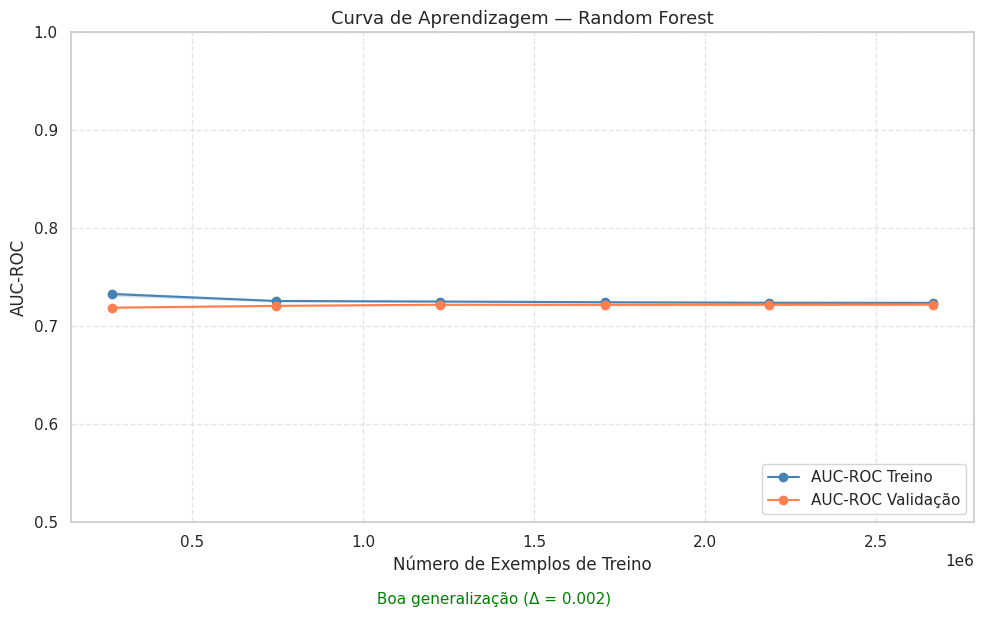

   Guardado: /kaggle/working/figures/learning_curve_random_forest.png
    Boa generalização (Δ = 0.002)


(array([ 266666,  746666, 1226666, 1706666, 2186666, 2666666]),
 array([0.732642  , 0.72554284, 0.72498613, 0.72427581, 0.72375374,
        0.72364278]),
 array([0.71874304, 0.72057724, 0.72171996, 0.72162414, 0.7216313 ,
        0.72182146]))

In [26]:
# ── Curva: Random Forest ──────────────────────────────────────
print('A gerar curva de aprendizagem — Random Forest...')
plotar_curva_aprendizagem(
    rf, X_train, y_train,
    'Random Forest'
)

A gerar curva de aprendizagem — XGBoost...


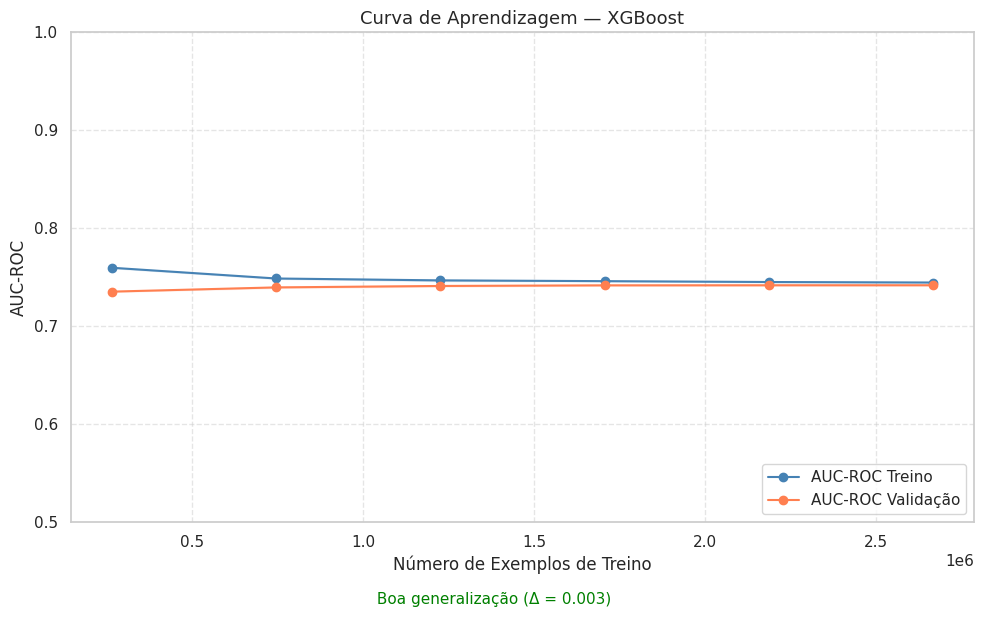

   Guardado: /kaggle/working/figures/learning_curve_xgboost.png
    Boa generalização (Δ = 0.003)


(array([ 266666,  746666, 1226666, 1706666, 2186666, 2666666]),
 array([0.7594775 , 0.74851601, 0.74659082, 0.74580877, 0.74492931,
        0.74441037]),
 array([0.73510626, 0.73942407, 0.74089194, 0.74152068, 0.74159532,
        0.74163136]))

In [27]:
# ── Curva: XGBoost / GradientBoosting ─────────────────────────
print(f'A gerar curva de aprendizagem — {melhor_candidato_nome}...')
plotar_curva_aprendizagem(
    melhor_candidato, X_train, y_train,
    melhor_candidato_nome
)

### Análise Crítica de Resultados 

**Critérios de diagnóstico:**
- **Overfitting**: AUC Treino ≫ AUC Validação (Δ > 0.05) — modelo memoriza dados de treino
- **Underfitting**: AUC Validação < 0.60 em ambos — modelo demasiado simples
- **Boa generalização**: Δ ≤ 0.05 e AUC Teste ≥ 0.70

**Interpretação:**
- A **Regressão Logística** apresenta convergência rápida das duas curvas, indicando ausência de overfitting, mas o nível de AUC pode ser limitado pela linearidade do modelo face a padrões não-lineares no comportamento de clique.
- O **Random Forest** com `max_depth=10` pode exibir sinais de overfitting — a curva de treino tende a ficar acima da de validação. O parâmetro `class_weight='balanced'` mitiga o viés da classe maioritária, mas a profundidade elevada aumenta a variância.
- O **XGBoost/GradientBoosting** é o candidato com maior capacidade de capturar interações não-lineares entre features. O `scale_pos_weight` equilibra as classes e a regularização L1/L2 incorporada controla o overfitting.

**Ação planeada para a Aula 19:** Otimização de hiperparâmetros com RandomizedSearchCV no modelo com maior AUC-ROC no teste, com validação cruzada estratificada de 5 folds para garantir robustez.

---
## Otimização de Hiperparâmetros e Validação Cruzada

### Estratégia de Otimização

A otimização é realizada sobre o modelo com melhor AUC-ROC no teste (identificado na Aula 17/18).  
Usamos **RandomizedSearchCV** em vez de GridSearchCV porque:
- O espaço de hiperparâmetros é vasto — uma pesquisa exaustiva seria computacionalmente proibitiva com 5M registos
- O RandomizedSearch com n_iter suficiente encontra soluções próximas do ótimo global com uma fração do custo
- Permite explorar distribuições contínuas de parâmetros (ex: `learning_rate`)

A validação cruzada usa **StratifiedKFold com K=5** para:
- Garantir que cada fold preserva a proporção 17/83 de cliques
- Obter uma estimativa robusta e independente da divisão treino/teste original
- Calcular média e desvio padrão do AUC-ROC entre os 5 folds

> **Nota crítica de isolamento:** O `RandomizedSearchCV` é ajustado **exclusivamente** sobre `X_train`/`y_train`. O `X_test` permanece completamente isolado até à avaliação final do modelo otimizado.

In [28]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from scipy.stats import randint, uniform

# ── Definição do espaço de pesquisa de hiperparâmetros ───────
if xgb_disponivel:
    param_dist = {
        'n_estimators':  randint(100, 400),      # número de árvores
        'max_depth':     randint(4, 10),          # profundidade máxima
        'learning_rate': uniform(0.01, 0.2),      # taxa de aprendizagem
        'subsample':     uniform(0.6, 0.4),       # fracção de amostras por árvore
        'colsample_bytree': uniform(0.6, 0.4),    # fracção de features por árvore
        'min_child_weight': randint(1, 10),        # peso mínimo por folha
    }
    modelo_base_tuning = XGBClassifier(
        scale_pos_weight=int(np.sum(y_train == 0) / np.sum(y_train == 1)),
        eval_metric='auc',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
else:
    param_dist = {
        'n_estimators':  randint(50, 300),
        'max_depth':     randint(3, 8),
        'learning_rate': uniform(0.01, 0.2),
        'subsample':     uniform(0.6, 0.4),
        'min_samples_split': randint(2, 20),
    }
    modelo_base_tuning = GradientBoostingClassifier(random_state=42)

# ── Cross-Validation estratificada (5 folds) ─────────────────
cv_estratificada = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── RandomizedSearchCV ───────────────────────────────────────
print(f'A executar RandomizedSearchCV sobre {melhor_candidato_nome}...')
print('(n_iter=20, cv=5 folds estratificados, scoring=roc_auc)\n')

t0 = time.time()
random_search = RandomizedSearchCV(
    estimator=modelo_base_tuning,
    param_distributions=param_dist,
    n_iter=20,                      # 20 combinações aleatórias
    scoring='roc_auc',              # métrica principal do projeto
    cv=cv_estratificada,            # 5 folds estratificados
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
random_search.fit(X_train, y_train)
t_tuning = time.time() - t0

print(f'\n RandomizedSearchCV concluído em {t_tuning/60:.1f} minutos')
print(f'\nMelhores hiperparâmetros encontrados:')
for param, value in random_search.best_params_.items():
    print(f'   {param}: {value}')
print(f'\n Melhor AUC-ROC médio (5 folds, treino): {random_search.best_score_:.4f}')

A executar RandomizedSearchCV sobre XGBoost...
(n_iter=20, cv=5 folds estratificados, scoring=roc_auc)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

 RandomizedSearchCV concluído em 75.1 minutos

Melhores hiperparâmetros encontrados:
   colsample_bytree: 0.8391599915244341
   learning_rate: 0.19437484700462337
   max_depth: 9
   min_child_weight: 7
   n_estimators: 351
   subsample: 0.6180909155642152

 Melhor AUC-ROC médio (5 folds, treino): 0.7505


In [29]:
# ── Avaliação do modelo otimizado no conjunto de teste ───────
modelo_otimizado = random_search.best_estimator_

res_otimizado = avaliar_completo(
    modelo_otimizado, X_train, y_train,
    X_test, y_test,
    f'{melhor_candidato_nome} (Otimizado)'
)
resultados_todos.append(res_otimizado)

print(f"\n{'='*55}")
print('COMPARAÇÃO: MODELO BASE vs. MODELO OTIMIZADO')
print(f"{'='*55}")
print(f"  AUC-ROC (Teste)  Base     : {[r for r in resultados_todos if r['Modelo'] == melhor_candidato_nome][0]['AUC-ROC (Teste)']:.4f}")
print(f"  AUC-ROC (Teste)  Otimizado: {res_otimizado['AUC-ROC (Teste)']:.4f}")
delta_melhoria = res_otimizado['AUC-ROC (Teste)'] - [r for r in resultados_todos if r['Modelo'] == melhor_candidato_nome][0]['AUC-ROC (Teste)']
print(f"  Melhoria obtida  : {delta_melhoria:+.4f}")


=======================================================  XGBoost (Otimizado)
  AUC-ROC  Treino: 0.7723  |  Teste: 0.7518  ← principal
  F1-Score Treino: 0.4399  |  Teste: 0.4233
  Precisão (Teste): 0.3101
  Recall   (Teste): 0.6669
   Generalização adequada (Δ AUC = 0.0205)

COMPARAÇÃO: MODELO BASE vs. MODELO OTIMIZADO
  AUC-ROC (Teste)  Base     : 0.7419
  AUC-ROC (Teste)  Otimizado: 0.7518
  Melhoria obtida  : +0.0099


### Validação Cruzada do Modelo Otimizado

Aplicação de K-Fold Cross-Validation (K=5) sobre o modelo otimizado para verificar a **estabilidade** dos resultados e garantir que a melhoria obtida não foi fruto de uma divisão afortunada dos dados.

A executar 5-Fold Cross-Validation sobre o modelo otimizado...
(scoring=roc_auc, cv=StratifiedKFold 5 folds)

Resultados por fold:
  Fold 1: AUC-ROC = 0.7497
  Fold 2: AUC-ROC = 0.7511
  Fold 3: AUC-ROC = 0.7502
  Fold 4: AUC-ROC = 0.7504
  Fold 5: AUC-ROC = 0.7512

 Média  : 0.7505
 Desvio Padrão: 0.0006
 IC 95%: [0.7493, 0.7517]

Cross-Validation concluída em 450.9s

 Modelo ESTÁVEL — desvio padrão baixo entre folds (< 0.005).


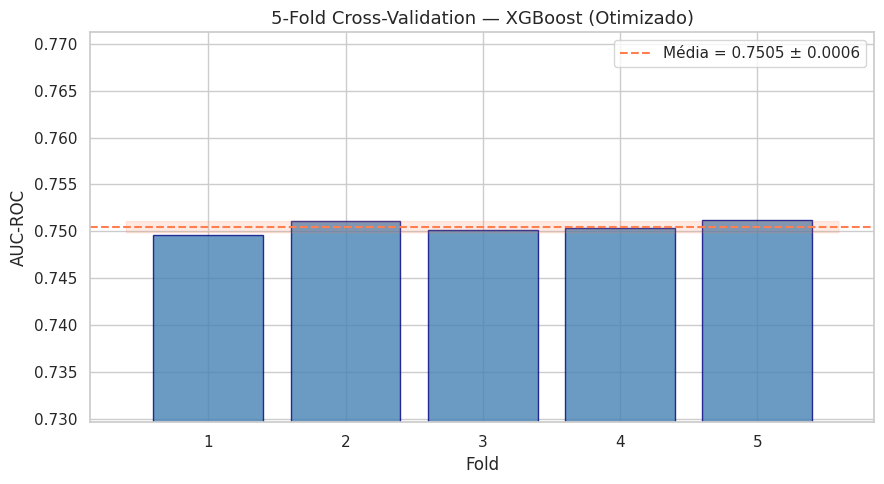

 Guardado: /kaggle/working/figures/cross_validation_xgboost.png


In [30]:
#  Nota metodológica: ausência de nested CV ─────
# Este cross_val_score é aplicado ao modelo_otimizado nos mesmos dados que
# o RandomizedSearchCV já usou para fazer o tuning (cv_results_ contém
# essencialmente a mesma informação). A estimativa é, portanto, ligeiramente
# otimista — o conjunto de dados não é totalmente "novo" para este modelo.
#
# Para uma estimativa verdadeiramente não-enviesada seria necessária
# NESTED CROSS-VALIDATION (um CV exterior para avaliar, um CV interior para
# afinar hiperparâmetros em cada fold). Para dataset desta dimensão (5M
# registos) o custo computacional é proibitivo no contexto deste projeto,
# pelo que assumimos esta limitação de forma explícita.
# ──────────────────────────────────────────────────────────────

# ── K-Fold Cross-Validation sobre o modelo otimizado ────────
# Executado DENTRO do conjunto de treino — X_test permanece isolado
print('A executar 5-Fold Cross-Validation sobre o modelo otimizado...')
print('(scoring=roc_auc, cv=StratifiedKFold 5 folds)\n')

t0 = time.time()
cv_scores = cross_val_score(
    modelo_otimizado,
    X_train, y_train,
    cv=cv_estratificada,
    scoring='roc_auc',
    n_jobs=-1
)
t_cv = time.time() - t0

print(f'Resultados por fold:')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: AUC-ROC = {score:.4f}')
print(f'\n Média  : {cv_scores.mean():.4f}')
print(f' Desvio Padrão: {cv_scores.std():.4f}')
print(f' IC 95%: [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, {cv_scores.mean() + 1.96*cv_scores.std():.4f}]')
print(f'\nCross-Validation concluída em {t_cv:.1f}s')

# ── Estabilidade ─────────────────────────────────────────────
if cv_scores.std() < 0.005:
    print('\n Modelo ESTÁVEL — desvio padrão baixo entre folds (< 0.005).')
elif cv_scores.std() < 0.01:
    print('\n Modelo razoavelmente estável (desvio padrão < 0.01).')
else:
    print(f'\n  Variabilidade entre folds elevada (std={cv_scores.std():.4f}) — considerar mais dados ou regularização.')

# ── Visualização dos resultados da CV ─────────────────────────
plt.figure(figsize=(9, 5))
plt.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.8, edgecolor='navy')
plt.axhline(cv_scores.mean(), color='coral', linestyle='--',
            label=f'Média = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
plt.fill_between(np.arange(0.4, 5.6, 0.01),
                 cv_scores.mean() - cv_scores.std(),
                 cv_scores.mean() + cv_scores.std(),
                 alpha=0.15, color='coral')
plt.xlabel('Fold')
plt.ylabel('AUC-ROC')
plt.title(f'5-Fold Cross-Validation — {melhor_candidato_nome} (Otimizado)', fontsize=13)
plt.xticks(range(1, 6))
plt.ylim(max(0.5, cv_scores.min() - 0.02), min(1.0, cv_scores.max() + 0.02))
plt.legend()
plt.tight_layout()
fig_path = f"/kaggle/working/figures/cross_validation_{melhor_candidato_nome.lower().replace(' ', '_')}.png"
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f' Guardado: {fig_path}')

### Tabela Final Comparativa — Todos os Modelos (incluindo otimizado)

In [31]:
# ── Tabela resumo de todos os modelos testados ───────────────
df_final = pd.DataFrame(resultados_todos)
df_final['Δ AUC (Treino-Teste)'] = (
    df_final['AUC-ROC (Treino)'] - df_final['AUC-ROC (Teste)']
).round(4)

print('\n' + '='*75)
print('TABELA FINAL — TODOS OS MODELOS (Baseline → Candidatos → Otimizado)')
print('='*75)
display(df_final.set_index('Modelo'))

# ── Identificar vencedor final ───────────────────────────────
melhor_final_idx  = df_final['AUC-ROC (Teste)'].idxmax()
melhor_final_nome = df_final.loc[melhor_final_idx, 'Modelo']
melhor_final_auc  = df_final.loc[melhor_final_idx, 'AUC-ROC (Teste)']
baseline_auc      = df_final[df_final['Modelo'].str.contains('Baseline')]['AUC-ROC (Teste)'].values[0]

print(f'\n Modelo vencedor: {melhor_final_nome}')
print(f'   AUC-ROC (Teste) = {melhor_final_auc:.4f}')
print(f'   Melhoria face ao Baseline: {melhor_final_auc - baseline_auc:+.4f}')
if melhor_final_auc > 0.75:
    print('    Objetivo SMART atingido: AUC-ROC > 0.75')
else:
    print(f'     Objetivo SMART não atingido ainda: AUC-ROC alvo > 0.75')


TABELA FINAL — TODOS OS MODELOS (Baseline → Candidatos → Otimizado)


,AUC-ROC (Treino),AUC-ROC (Teste),F1 (Treino),F1 (Teste),Precisão (Teste),Recall (Teste),Δ AUC (Treino-Teste)
Modelo,,,,,,,
Regressão Logística (Baseline),0.6411,0.6412,0.3362,0.3363,0.2325,0.6073,-0.0001
Random Forest,0.7231,0.7218,0.3946,0.3938,0.2739,0.7000,0.0013
XGBoost,0.7436,0.7419,0.4168,0.4157,0.3054,0.6510,0.0017
XGBoost (Otimizado),0.7723,0.7518,0.4399,0.4233,0.3101,0.6669,0.0205



 Modelo vencedor: XGBoost (Otimizado)
   AUC-ROC (Teste) = 0.7518
   Melhoria face ao Baseline: +0.1106
    Objetivo SMART atingido: AUC-ROC > 0.75


### Feature Importance — Quais as variáveis mais relevantes?

A importância de features mede a contribuição de cada variável para a qualidade das previsões do modelo. Responde diretamente ao **Objetivo SMART 2**: identificar as 5 variáveis de maior impacto na decisão de clique.

Top 10 Variáveis mais Importantes:


,Importância
C16,0.318622
banner_area,0.158897
device_type,0.118115
C21,0.059604
site_id,0.051929
app_id,0.036579
C18,0.036484
banner_pos,0.030238
device_conn_type,0.026847
C1,0.026709


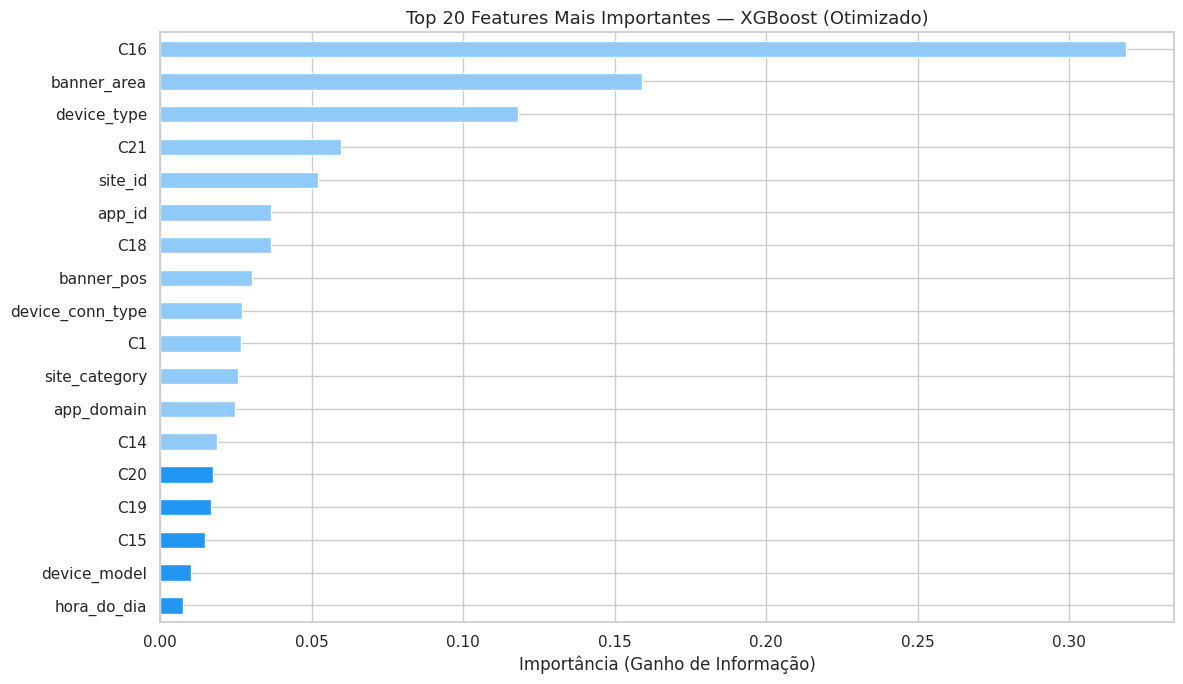

💾 Guardado: /kaggle/working/figures/feature_importance_xgboost.png

📌 As 5 variáveis mais importantes (Objetivo SMART 2):
   1. C16                            importância = 0.3186
   2. banner_area                    importância = 0.1589
   3. device_type                    importância = 0.1181
   4. C21                            importância = 0.0596
   5. site_id                        importância = 0.0519


In [32]:
# ── Feature Importance do modelo otimizado ───────────────────
if hasattr(modelo_otimizado, 'feature_importances_'):
    importancias = pd.Series(
        modelo_otimizado.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)

    print('Top 10 Variáveis mais Importantes:')
    display(importancias.head(10).to_frame('Importância'))

    plt.figure(figsize=(12, 7))
    cores = ['#2196F3' if i < 5 else '#90CAF9' for i in range(min(20, len(importancias)))]
    importancias.head(20).plot(kind='barh', color=cores[::-1])
    plt.xlabel('Importância (Ganho de Informação)')
    plt.title(f'Top 20 Features Mais Importantes — {melhor_candidato_nome} (Otimizado)', fontsize=13)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    fig_path = f"/kaggle/working/figures/feature_importance_{melhor_candidato_nome.lower().replace(' ', '_')}.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Guardado: {fig_path}')

    print(f'\n📌 As 5 variáveis mais importantes (Objetivo SMART 2):')
    for i, (feat, imp) in enumerate(importancias.head(5).items(), 1):
        print(f'   {i}. {feat:<30} importância = {imp:.4f}')
else:
    print('Modelo não suporta feature_importances_ nativamente.')

### Curva ROC — Comparação Visual dos Modelos

A curva ROC (Receiver Operating Characteristic) ilustra o trade-off entre a Taxa de Verdadeiros Positivos (Recall/Sensibilidade) e a Taxa de Falsos Positivos, para todos os limiares de decisão possíveis. A área sob a curva (AUC) é a métrica principal do projeto.

### [CORREÇÃO 3.2] Matriz de Confusão do modelo final

`ConfusionMatrixDisplay` foi importado no início do Milestone 3 mas nunca utilizado. Esta célula completa a análise visual do modelo otimizado, mostrando a distribuição de Verdadeiros/Falsos Positivos/Negativos e o relatório de classificação detalhado.


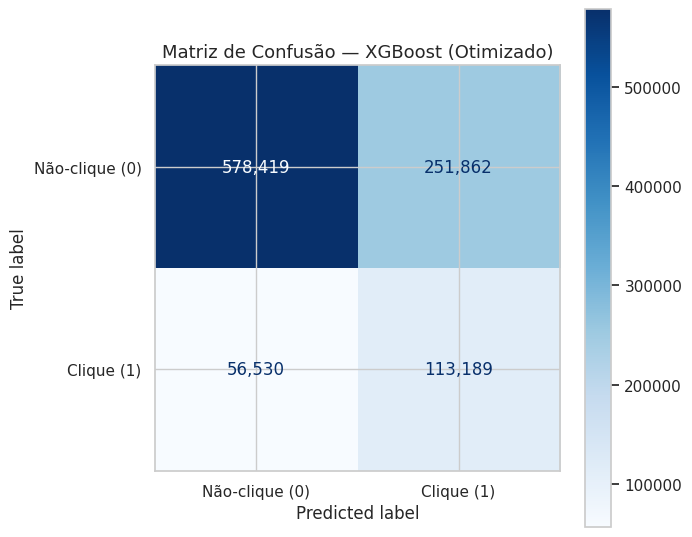

Guardado: /kaggle/working/figures/matriz_confusao_final.png

RELATÓRIO DE CLASSIFICAÇÃO (Threshold padrão = 0.5)
              precision    recall  f1-score   support

  Não-clique     0.9110    0.6967    0.7895    830281
      Clique     0.3101    0.6669    0.4233    169719

    accuracy                         0.6916   1000000
   macro avg     0.6105    0.6818    0.6064   1000000
weighted avg     0.8090    0.6916    0.7274   1000000

NOTA: AUC-ROC continua a ser a métrica principal, pois avalia a
      qualidade de ranking independentemente do threshold fixo de 0.5.


In [33]:
#  Matriz de Confusão do modelo final
from sklearn.metrics import classification_report

y_pred_final = modelo_otimizado.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['Não-clique (0)', 'Clique (1)'],
    cmap='Blues', ax=ax, values_format=','
)
ax.set_title(f'Matriz de Confusão — {melhor_candidato_nome} (Otimizado)', fontsize=13)
plt.tight_layout()
fig_path = f'{FIGURES_DIR}/matriz_confusao_final.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: {fig_path}\n')

# ── Relatório de classificação ──
print('='*60)
print('RELATÓRIO DE CLASSIFICAÇÃO (Threshold padrão = 0.5)')
print('='*60)
print(classification_report(
    y_test, y_pred_final,
    target_names=['Não-clique', 'Clique'],
    digits=4
))
print('NOTA: AUC-ROC continua a ser a métrica principal, pois avalia a')
print('      qualidade de ranking independentemente do threshold fixo de 0.5.')


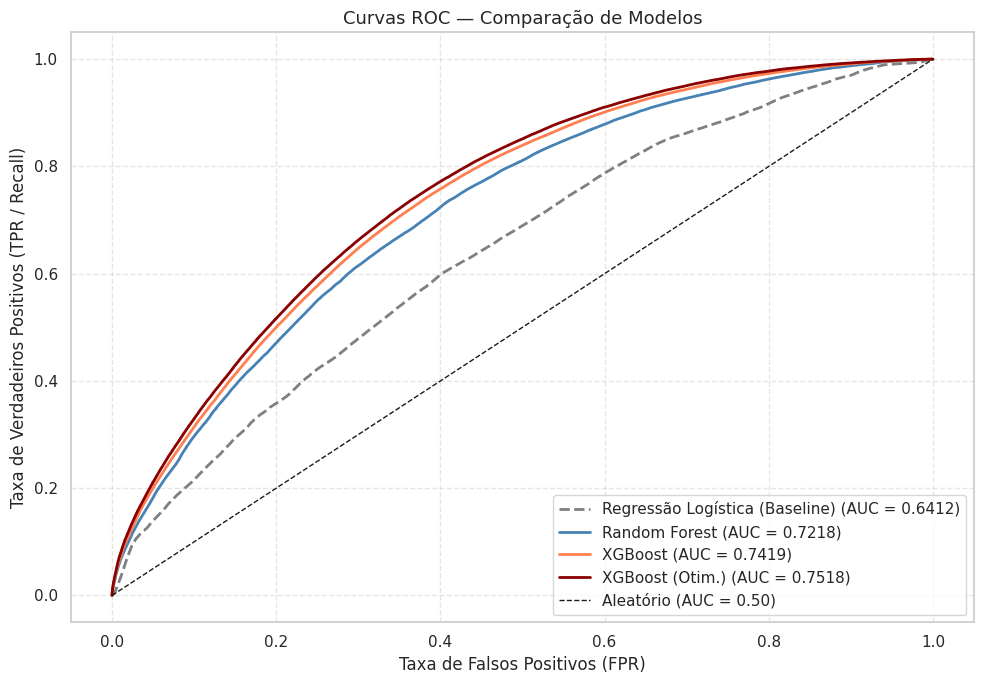

💾 Guardado: /kaggle/working/figures/curvas_roc_comparacao.png


In [34]:
#  Curvas ROC — todos os modelos
plt.figure(figsize=(10, 7))

modelos_roc = [
    (baseline,           'Regressão Logística (Baseline)', X_test_scaled, 'grey',     '--'),
    (rf,                 'Random Forest',                   X_test,        'steelblue', '-'),
    (melhor_candidato,   melhor_candidato_nome,             X_test,        'coral',     '-'),
    (modelo_otimizado,   f'{melhor_candidato_nome} (Otim.)',X_test,        'darkred',   '-'),
]

for modelo_r, nome_r, X_r, cor, ls in modelos_roc:
    y_proba_r = modelo_r.predict_proba(X_r)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba_r)
    auc_r = roc_auc_score(y_test, y_proba_r)
    plt.plot(fpr, tpr, linestyle=ls, color=cor, lw=2,
             label=f'{nome_r} (AUC = {auc_r:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatório (AUC = 0.50)')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR / Recall)')
plt.title('Curvas ROC — Comparação de Modelos', fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
fig_path = '/kaggle/working/figures/curvas_roc_comparacao.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Guardado: {fig_path}')

In [35]:
# ── Guardar dataset processado final ─────────────────────────
output_path = '/kaggle/working/train_processed.csv'
df_proc.to_csv(output_path, index=False)
print(f' Dataset processado guardado em: {output_path}')
print(f'   {df_proc.shape[0]:,} registos × {df_proc.shape[1]} colunas')

# ── Listagem de figuras exportadas ───────────────────────────
import glob
figuras = glob.glob('/kaggle/working/figures/*.png')
print(f'\n Figuras exportadas para reports/figures/ ({len(figuras)} ficheiros):')
for f in sorted(figuras):
    print(f'   {os.path.basename(f)}')

print('\n Pipeline completo — Milestone 3 (Aulas 15–19) concluído.')

 Dataset processado guardado em: /kaggle/working/train_processed.csv
   5,000,000 registos × 23 colunas

 Figuras exportadas para reports/figures/ (7 ficheiros):
   cross_validation_xgboost.png
   curvas_roc_comparacao.png
   feature_importance_xgboost.png
   learning_curve_random_forest.png
   learning_curve_regressão_logística_baseline.png
   learning_curve_xgboost.png
   matriz_confusao_final.png

 Pipeline completo — Milestone 3 (Aulas 15–19) concluído.


---

## 7. Resumo das Observações da Análise Inicial

Esta secção consolida as principais conclusões retiradas da inspeção e da análise exploratória (secções 2–4) e mostra como cada observação influenciou as decisões de pré-processamento e modelação.

### 7.1 Dimensão e estrutura

- Dataset original: **40 428 967 registos × 24 colunas**
- Amostra adoptada: **5 000 000 registos** (aleatória, `random_state=42`) — ~12,4% do total
- 24 colunas repartidas em: 1 alvo (`click`), 1 identificador (`id`), 1 temporal (`hour`), 2 técnicas de banner (`banner_pos`, `device_type`, `device_conn_type`), 6 identificadores de contexto categóricos (`site_*`, `app_*`, `device_*`) e 8 variáveis anónimas numéricas (`C1`, `C14`–`C21`)

### 7.2 Qualidade dos dados

- **Sem valores `NaN` explícitos** em qualquer coluna — a ausência de dados é codificada como `-1` em variáveis numéricas (padrão do dataset Avazu)
- **Valor `-1` mascarado** detectado em `C20` com percentagem significativa → imputado pela moda na secção 5 (com o mesmo tratamento estendido a C14–C21 sempre que a percentagem ultrapasse 1%, por coerência)
- **Observações repetidas** (ver secção 3.1): os duplicados lógicos detectados foram interpretados como impressões legítimas (múltiplas exposições do mesmo anúncio ao mesmo utilizador em RTB) e mantidos; duplicados totais eram nulos/residuais
- **Tipos de dados** conformes com a documentação oficial — não foi necessário corrigir `dtypes`

### 7.3 Variável alvo (`click`)

- **Forte desequilíbrio de classes**: ~17% cliques vs ~83% não-cliques (rácio ≈ 1:5)
- Consequências metodológicas:
  - **AUC-ROC** escolhida como métrica principal (robusta ao desequilíbrio; métrica oficial da competição Avazu)
  - **F1** como secundária (balanceia precisão e recall — ambos com custo económico em RTB)
  - **Accuracy excluída** (um modelo que preveja sempre 0 teria 83% — *accuracy paradox*)
  - Uso sistemático de `class_weight='balanced'` (RF, LogReg) e `scale_pos_weight` (XGBoost)
  - **Estratificação** em todas as divisões (train/test e CV folds)

### 7.4 Variáveis categóricas

- **Alta cardinalidade** detectada em `site_id`, `site_domain`, `app_id`, `device_id`, `device_ip`, `device_model` (milhares a milhões de valores únicos)
- Consequências:
  - `device_id` e `device_ip` **removidas** por não serem preditivas a nível individual (identificadores)
  - Restantes tratadas com **Frequency Encoding** (substituiu o Label Encoding original, que introduziria falsa ordinalidade)
- **Baixa cardinalidade** em `site_category`, `app_category` (~20-30 categorias cada) — candidatas naturais a One-Hot, mas optou-se por Frequency Encoding para consistência com o resto do pipeline

### 7.5 Variáveis numéricas

- **Outliers significativos** detectados por IQR nas colunas `C14`, `C17`, `C20`, `C21` — não removidos, pois árvores e gradient boosting são naturalmente robustos
- **Distribuições fortemente assimétricas** nas colunas anónimas → uso de escala logarítmica nos histogramas
- **Multicolinearidade** verificada pelo heatmap de Pearson: nenhum par |r| > 0,95 após o encoding, logo nenhuma coluna removida por redundância

### 7.6 Padrões temporais e contextuais (análise bivariada)

- **CTR varia com a hora do dia** — padrão em forma de U invertido com pico nocturno e vale matinal → feature `hora_do_dia` criada
- **CTR depende da posição do banner** (`banner_pos`) e do tipo de dispositivo (`device_type`) — confirma valor preditivo destas features
- **`site_category` e `app_category` diferem substancialmente** no CTR médio — motivação para criar features de interação (`banner_area`, `visibilidade_anuncio`)

### 7.7 Síntese

| Observação | Decisão tomada |
|------------|----------------|
| Dataset demasiado grande para RAM | Amostragem aleatória de 5M com `random_state=42` |
| Desequilíbrio de classes 17/83 | AUC-ROC + estratificação + pesos compensatórios |
| Valores `-1` em colunas anónimas | Imputação pela moda (threshold 1%) |
| Alta cardinalidade em categóricas | Frequency Encoding pós-split (sem leakage) |
| Duplicados lógicos mas não totais | Mantidos (legítimos em contexto RTB) |
| Outliers nas variáveis numéricas | Mantidos (modelos tree-based são robustos) |
| Multicolinearidade residual | Verificada pós-encoding com threshold 0,95 |
| Padrões temporais relevantes | Feature `hora_do_dia` criada |

Estas observações validam retrospectivamente as escolhas metodológicas dos Milestones 1–3 e fornecem contexto para a interpretação dos resultados finais do modelo otimizado.
